In [38]:
import json
import numpy as np
import pandas as pd
import os

### Derriving mapping

In [39]:
with open("cfsort_full_map_dict_v2.json", "rb") as f:
    tissue_mapping_dict = json.load(f)

In [40]:
LOYFER_CONFIDENCE_LEVELS = [
    "loyfer_counts_manual_legacy",
    "loyfer_counts_ontology_and_manual",  # Exact Ontology match + hierarchical match + manual curation. WARNING: Produces spurious matches, hence, unusable.
    "loyfer_counts_lenient",  # Exact Ontology match + hierarchical match + manual curation + match by keyword. WARNING: Produces spurious matches, hence, unusable.
    "loyfer_counts_strict",  # Exact Ontology match + manual curation
]

In [41]:
def get_expected_cell_types(
    tissue_dict,
    threshold,
    exclude_keys=("unmapped",),
    loyfer_confidence_level="loyfer_counts_ontology_and_manual",
):
    """
    Build a DataFrame of expected cell types per tissue based on a loyfer_counts
    percentage threshold.

    Parameters
    ----------
    tissue_dict : dict
        Dictionary keyed by tissue name (cfsort_name), with each value containing
        a loyfer_confidence_level sub-dict.
    threshold : float
        Minimum percentage (0-1 scale, e.g. 0.05 for 5%) a cell type must reach
        to be included in expected_cell_types.
    exclude_keys : tuple of str
        Keys to always exclude from consideration (default: ('unmapped',)).

    Returns
    -------
    pd.DataFrame
        Columns: cfsort_tissue_name, expected_cell_types, final_mapping_rate
    """
    rows = []
    for tissue_name, tissue_data in tissue_dict.items():
        loyfer_counts = tissue_data.get(loyfer_confidence_level, {}) or {}

        # Filter out excluded keys before computing the total so percentages
        # are relative to the "mappable" pool. If you'd rather keep 'unmapped'
        # in the denominator, move this filtering to after the total is computed.
        filtered = {k: v for k, v in loyfer_counts.items() if k not in exclude_keys}

        total = sum(loyfer_counts.values())

        if total == 0:
            rows.append(
                {
                    "cfsort_tissue_name": tissue_name,
                    "expected_cell_types": [],
                    "final_mapping_rate": 0.0,
                }
            )
            continue

        # Build (cell_type, percentage) pairs and filter by threshold
        passing = [
            (ct, cnt / total)
            for ct, cnt in filtered.items()
            if (cnt / total) >= threshold
        ]

        # Sort by percentage descending for readability
        passing.sort(key=lambda x: x[1], reverse=True)

        expected_cell_types = [ct for ct, _ in passing]
        final_mapping_rate = round(sum(p for _, p in passing), 4)

        rows.append(
            {
                "cfsort_tissue_name": tissue_name,
                "expected_cell_types": expected_cell_types,
                "final_mapping_rate": final_mapping_rate,
            }
        )

    return pd.DataFrame(
        rows,
        columns=["cfsort_tissue_name", "expected_cell_types", "final_mapping_rate"],
    )

In [42]:
tissue_mapping_df = get_expected_cell_types(
    tissue_dict=tissue_mapping_dict,
    threshold=0.01,
    loyfer_confidence_level="loyfer_counts_strict",
)
tissue_mapping_df = tissue_mapping_df[tissue_mapping_df["final_mapping_rate"] > 0.7]

In [43]:
# for i in range(len(tissue_mapping_df)):
#     tissue = tissue_mapping_df["cfsort_tissue_name"].to_numpy()[i]
#     if "unmapped" in tissue_mapping_dict[tissue]["loyfer_counts_strict"].keys():
#         # if tissue_mapping_dict[tissue]["loyfer_counts_strict"]["unmapped"] != tissue_mapping_dict[tissue]["loyfer_counts_manual_legacy"]["unmapped"]:
#         if True:
#             print(tissue)
#             # print(tissue_mapping_dict[tissue]["loyfer_counts_ontology_and_manual"])
#             print(tissue_mapping_dict[tissue]["loyfer_counts_strict"]["unmapped"] / np.sum(list(tissue_mapping_dict[tissue]["loyfer_counts_strict"].values())))
#             print(tissue_mapping_dict[tissue]["loyfer_counts_manual_legacy"])
#             print(tissue_mapping_dict[tissue]["loyfer_counts_strict"])

#             # print(set(tissue_mapping_dict[tissue]["loyfer_counts_ontology_and_manual"]).difference(tissue_mapping_dict[tissue]["loyfer_counts_manual_legacy"]))

In [44]:
# end = []
# for (key, value) in tissue_mapping_dict.items():
#     counts = value.get("loyfer_counts_strict")
#     n_samples = int(np.sum(uxm_results["Biosample term name"]==key)/39)
#     if counts:
#         end.extend([counts.get("Blood-T",0)/ np.sum(list(counts.values()))]*n_samples)

In [45]:
# np.mean(end)

In [46]:
cell_types_names_correction_map = {
    "Adipocytes": "Adipocytes",
    "Bladder-Ep": "Bladder-Ep",
    "Blood-B": "Blood-B",
    "Blood-Granul": "Blood-Granul",
    "Blood-Mono+Macro": "Blood-Mono+Macro",
    "Blood-NK": "Blood-NK",
    "Blood-T": "Blood-T",
    "Breast-Basal-Ep": "Breast-Basal-Ep",
    "Breast-Luminal-Ep": "Breast-Luminal-Ep",
    "Colon-Fibro": "Colon-Fibro",
    "Endothelium": "Endothel",
    "Eryth-prog": "Eryth-prog",
    "Fallopian-Ep": "Fallopian-Ep",
    "Head-Neck-Ep": "Head-Neck-Ep",
    "Heart-Cardio": "Heart-Cardio",
    "Heart-Fibro": "Heart-Fibro",
    "Kidney-Ep": "Kidney-Ep",
    "Liver-Hep": "Liver-Hep",
    "Lung-Ep-Alveo": "Lung-Ep-Alveo",
    "Lung-Ep-Bron": "Lung-Ep-Bron",
    "Ovary+Endom-Ep": "Ovary-Ep",
    "Pancreas-Acinar": "Pancreas-Acinar",
    "Pancreas-Duct": "Pancreas-Duct",
    "Prostate-Ep": "Prostate-Ep",
    "Small-Int-Ep": "Small-Int-Ep",
    "Smooth-Musc": "Smooth-Musc",
    "Dermal-Fibro": "Dermal-Fibro",
    "Epid-Kerat": "Epid-Kerat",
    "Gastric-Ep": "Gastric-Ep",
}

In [47]:
expected_cell_types = []
for item in tissue_mapping_df["expected_cell_types"]:
    expected_cell_types.append(
        [cell_types_names_correction_map[cell_type] for cell_type in item]
    )

In [48]:
tissue_mapping_df["expected_cell_types"] = expected_cell_types

In [49]:
# all_types = []

# [all_types.extend(x) for x in tissue_mapping_df["expected_cell_types"].to_numpy()]


In [50]:
# pd.Series(all_types).value_counts()

In [51]:
print(tissue_mapping_df.to_string())

   cfsort_tissue_name                                                                                              expected_cell_types  final_mapping_rate
0                skin                                   [Blood-T, Dermal-Fibro, Blood-Mono+Macro, Blood-Granul, Endothel, Smooth-Musc]              0.9655
4      salivary gland              [Head-Neck-Ep, Blood-T, Blood-B, Dermal-Fibro, Blood-Mono+Macro, Endothel, Epid-Kerat, Smooth-Musc]              0.8725
8               liver                    [Liver-Hep, Blood-Mono+Macro, Blood-T, Endothel, Eryth-prog, Blood-B, Blood-Granul, Blood-NK]              0.9463
9            pancreas                              [Pancreas-Acinar, Pancreas-Duct, Endothel, Blood-Mono+Macro, Blood-T, Dermal-Fibro]              0.9488
10    small intestine                                                 [Small-Int-Ep, Blood-T, Blood-B, Dermal-Fibro, Blood-Mono+Macro]              0.9760
11            stomach                           [Blood-Mono+Macro, Blo

### Define helpers

In [52]:
import pandas as pd


def pivot_results(
    df,
    config_cols=("Classifier", "Deconvolver", "Calibrator"),
    value_col="PredictedProportion",
    id_cols=(
        "CellType",
        "file",
        "Biosample organism",
        "Biosample type",
        "Biosample term name",
    ),
    sep="__",
):
    """
    Pivot results so each (Classifier, Deconvolver, Calibrator)
    combination becomes its own column of PredictedProportion values.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format results.
    config_cols : tuple of str
        Columns whose combinations define each method variant.
    value_col : str
        Column to spread into the new method columns.
    id_cols : tuple of str
        Columns identifying each row in the wide output.
    sep : str
        Separator used when joining config values into a column name.

    Returns
    -------
    pd.DataFrame
        Wide-format dataframe with one column per method combination.
    """
    config_cols = list(config_cols)
    id_cols = list(id_cols)

    # Combine the config columns into a single method label, e.g.
    # "AttnClassifier__MethylBERT__LCal"
    work = df.copy()
    work["_method"] = work[config_cols].astype(str).agg(sep.join, axis=1)

    # Sanity check: each (id, method) pair should be unique.
    dupes = work.duplicated(subset=id_cols + ["_method"])
    if dupes.any():
        n = int(dupes.sum())
        raise ValueError(
            f"{n} duplicate (id_cols, method) rows found — "
            "pivot would silently drop or aggregate them. Investigate before pivoting."
        )

    wide = work.pivot(index=id_cols, columns="_method", values=value_col)
    wide = wide.reset_index()
    wide.columns.name = None

    return wide

In [53]:
import pandas as pd


def compute_on_target_proportions(
    deconv_df,
    expected_df,
    method_columns,
    biosample_col="Biosample term name",
    file_col="file",
    celltype_col="CellType",
):
    """
    Compute the proportion of predicted signal that falls on expected cell types,
    per file + biosample, for each specified deconvolution method.

    Parameters
    ----------
    deconv_df : pd.DataFrame
        Deconvolution results. Must contain `celltype_col`, `file_col`,
        `biosample_col`, and all columns listed in `method_columns`.
    expected_df : pd.DataFrame
        Output of `get_expected_cell_types`, with columns
        ['cfsort_tissue_name', 'expected_cell_types', 'final_mapping_rate'].
    method_columns : list of str
        Deconvolution method columns to evaluate, e.g. ['UXM_U25', 'UXM_U250'].
    biosample_col, file_col, celltype_col : str
        Column names in `deconv_df`.

    Returns
    -------
    pd.DataFrame
        One row per (file, biosample) with on-target proportions per method,
        plus the corresponding expected_cell_types and final_mapping_rate
        for reference.
    """
    # Accept a single method as a string too
    if isinstance(method_columns, str):
        method_columns = [method_columns]

    # Merge expected cell types onto each deconvolution row via the biosample.
    # Left join keeps deconv rows even if there's no expected mapping.
    merged = deconv_df.merge(
        expected_df,
        how="left",
        left_on=biosample_col,
        right_on="cfsort_tissue_name",
    )

    # Flag rows whose CellType is in the per-tissue expected list.
    # Handle NaN (missing mapping) and non-list values safely.
    def _is_on_target(row):
        expected = row["expected_cell_types"]
        if not isinstance(expected, list):
            return False
        return row[celltype_col] in expected

    merged["on_target"] = merged.apply(_is_on_target, axis=1)

    # For each method, on-target proportion = sum of proportions where on_target is True
    group_keys = [file_col, biosample_col]
    agg_rows = []

    for (file_id, biosample), grp in merged.groupby(group_keys, dropna=False):
        row = {file_col: file_id, biosample_col: biosample}

        # Carry over the expected list and final_mapping_rate (same within group)
        row["expected_cell_types"] = (
            grp["expected_cell_types"].iloc[0]
            if isinstance(grp["expected_cell_types"].iloc[0], list)
            else []
        )
        row["final_mapping_rate"] = grp["final_mapping_rate"].iloc[0]

        on_target_mask = grp["on_target"]
        for method in method_columns:
            on_target_sum = grp.loc[on_target_mask, method].sum()
            row[f"{method}"] = round(float(on_target_sum), 4)

        agg_rows.append(row)

    result = pd.DataFrame(agg_rows)

    # Nice column order
    method_cols_out = [f"{m}" for m in method_columns]
    result = result[
        [file_col, biosample_col, "expected_cell_types", "final_mapping_rate"]
        + method_cols_out
    ]

    return result

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

_TEST_FUNCS = {
    "wilcoxon": lambda a, b: stats.wilcoxon(a, b),
    "ttest_rel": lambda a, b: stats.ttest_rel(a, b),
    "ttest_ind": lambda a, b: stats.ttest_ind(a, b, equal_var=False),
    "mannwhitney": lambda a, b: stats.mannwhitneyu(a, b, alternative="two-sided"),
}
_PAIRED_TESTS = {"wilcoxon", "ttest_rel"}


def _run_test(df, a_name, b_name, test):
    """Run `test` between two columns; return p-value or nan on failure."""
    if test in _PAIRED_TESTS:
        pair = df[[a_name, b_name]].dropna()
        a, b = pair[a_name].values, pair[b_name].values
    else:
        a = df[a_name].dropna().values
        b = df[b_name].dropna().values
    try:
        return float(_TEST_FUNCS[test](a, b).pvalue)
    except ValueError:
        return np.nan

_CORRECTIONS = ("bonferroni", "holm", "fdr_bh", "fdr_by")


def _step_adjust(v, weights, accumulate):
    """Sort, scale by `weights`, enforce monotonicity, unsort."""
    n = len(v)
    order_idx = np.argsort(v)
    adj_ranked = v[order_idx] * weights(n)
    adj_ranked = np.minimum(accumulate(adj_ranked), 1.0)
    out = np.empty(n)
    out[order_idx] = adj_ranked
    return out


def _apply_correction(pvals, correction):
    """Apply multiple-testing correction to a 1-D array of p-values."""
    pvals = np.asarray(pvals, dtype=float)
    valid = ~np.isnan(pvals)
    adj = np.full_like(pvals, np.nan, dtype=float)
    v = pvals[valid]
    if correction == "bonferroni":
        adj[valid] = np.minimum(v * valid.sum(), 1.0)
    elif correction == "holm":
        # step-down: k-th smallest scaled by (n - k + 1), running max forward
        adj[valid] = _step_adjust(
            v,
            lambda n: n - np.arange(n),
            np.maximum.accumulate,
        )
    elif correction == "fdr_bh":
        # step-up: k-th smallest scaled by n/k, running min backward
        adj[valid] = _step_adjust(
            v,
            lambda n: n / (np.arange(n) + 1),
            lambda x: np.minimum.accumulate(x[::-1])[::-1],
        )
    elif correction == "fdr_by":
        # Benjamini-Yekutieli: BH with an extra harmonic factor
        # H_n = sum(1/i), which buys FDR control under *arbitrary*
        # dependence rather than only independence/PRDS.
        adj[valid] = _step_adjust(
            v,
            lambda n: n * np.sum(1.0 / np.arange(1, n + 1)) / (np.arange(n) + 1),
            lambda x: np.minimum.accumulate(x[::-1])[::-1],
        )
    else:
        raise ValueError(f"correction must be None or one of {list(_CORRECTIONS)}")
    return adj


def pairwise_pvalue_matrix(df, methods, test="wilcoxon", correction=None):
    """
    Compute a symmetric pairwise p-value matrix for a set of methods.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe where each column is a method's scores.
    methods : list of str
        Method names (column labels in `df`) to compare. The output matrix
        is indexed in this order.
    test : {'wilcoxon', 'ttest_rel', 'ttest_ind', 'mannwhitney'}
        Statistical test. Paired tests ('wilcoxon', 'ttest_rel') drop rows
        with missing values for either method in the pair; unpaired tests
        drop missing values per method independently.
    correction : {None, 'bonferroni', 'fdr_bh'}
        Optional multiple-testing correction applied across the unique
        pairs (the upper triangle of the matrix, n*(n-1)/2 comparisons).
        When set, the returned matrix contains corrected p-values.

    Returns
    -------
    pandas.DataFrame
        Square symmetric matrix of p-values, indexed and columned by
        method name. The diagonal is NaN. Tests that fail (e.g. Wilcoxon
        on identical paired samples) also yield NaN.
    """
    if test not in _TEST_FUNCS:
        raise ValueError(f"test must be one of {list(_TEST_FUNCS)}")
    if correction is not None and correction not in _CORRECTIONS:
        raise ValueError(f"correction must be None or one of {list(_CORRECTIONS)}")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")
    if len(methods) < 2:
        raise ValueError("need at least 2 methods to compute pairwise comparisons")

    n = len(methods)
    # Compute upper triangle once and mirror it.
    pair_indices = [(i, j) for i in range(n) for j in range(i + 1, n)]
    pvals = np.array(
        [_run_test(df, methods[i], methods[j], test) for i, j in pair_indices]
    )

    if correction is not None:
        pvals = _apply_correction(pvals, correction)

    mat = np.full((n, n), np.nan, dtype=float)
    for (i, j), p in zip(pair_indices, pvals):
        mat[i, j] = p
        mat[j, i] = p

    return pd.DataFrame(mat, index=methods, columns=methods)

In [55]:
def pairwise_tissue_count_matrices(
    df, methods, group_col, alpha=0.05, test="ttest_rel", scale=100.0
):
    """
    Per-group win/loss tallies and a sign test, for every method pair.

    Each group (e.g. a tissue) is tested on its own samples, and the
    results are summarised as counts rather than pooled into one number.
    Nothing here depends on the other method pairs, so a cell's content
    never changes because of what else is in the figure.

    Parameters
    ----------
    df : pandas.DataFrame
        One row per sample, one column per method, plus `group_col`.
        Pass the *un-aggregated* frame -- the grouping is done here.
    methods : list of str
        Method names (column labels in `df`).
    group_col : str
        Column holding the group label (tissue).
    alpha : float
        Per-group significance threshold for the win/loss tallies.
    test : {'ttest_rel', 'wilcoxon'}
        Paired test applied within each group.
    scale : float
        Multiplier for the reported differences (100 for TCS points).

    Returns
    -------
    (center, up, down, sign_p)
        Square DataFrames. For entry (i, j), describing `methods[i]`
        against `methods[j]`:
          center : mean over groups of the per-group mean difference,
                   so every group counts once regardless of how many
                   samples it holds
          up     : number of groups favouring methods[i] at p < alpha
          down   : number of groups favouring methods[j] at p < alpha
          sign_p : two-sided exact binomial p-value on the number of
                   groups methods[i] wins (ties dropped), i.e. a sign
                   test of "does i beat j more often than chance"
        `up`/`down` swap and `center` negates under transposition;
        `sign_p` is symmetric. The diagonal is NaN.

    Notes
    -----
    The sign test asks whether the *direction* is consistent across
    groups and ignores how large each gap is, which makes it the natural
    counterpart to the count display. It is exact and distribution-free,
    and being a single test per pair it needs no multiplicity adjustment
    across pairs.
    """
    if test not in _PAIRED_TESTS:
        raise ValueError(f"test must be one of {sorted(_PAIRED_TESTS)}")
    if group_col not in df.columns:
        raise ValueError(f"group_col {group_col!r} not found in df")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")
    methods = list(methods)
    if len(methods) < 2:
        raise ValueError("need at least 2 methods to compute pairwise comparisons")

    n = len(methods)
    groups = list(df.groupby(group_col))

    center = np.full((n, n), np.nan, dtype=float)
    up = np.full((n, n), np.nan, dtype=float)
    down = np.full((n, n), np.nan, dtype=float)
    sign_p = np.full((n, n), np.nan, dtype=float)

    for i, j in [(i, j) for i in range(n) for j in range(i + 1, n)]:
        a, b = methods[i], methods[j]
        deltas, n_up, n_down = [], 0, 0
        for _, g in groups:
            pair = g[[a, b]].dropna()
            if pair.empty:
                continue
            delta = (pair[a].mean() - pair[b].mean()) * scale
            deltas.append(delta)
            if len(pair) < 2:
                continue  # cannot test a single sample
            try:
                p = float(_TEST_FUNCS[test](pair[a].values, pair[b].values).pvalue)
            except ValueError:
                continue  # e.g. wilcoxon on all-zero differences
            if np.isnan(p) or p >= alpha:
                continue
            if delta > 0:
                n_up += 1
            elif delta < 0:
                n_down += 1

        if not deltas:
            continue
        deltas = np.asarray(deltas)
        m = float(deltas.mean())
        # Sign test on direction; ties carry no directional information.
        untied = deltas[deltas != 0]
        p_sign = (
            float(stats.binomtest(int((untied > 0).sum()), len(untied)).pvalue)
            if len(untied)
            else np.nan
        )

        center[i, j], up[i, j], down[i, j], sign_p[i, j] = m, n_up, n_down, p_sign
        center[j, i], up[j, i], down[j, i], sign_p[j, i] = -m, n_down, n_up, p_sign

    def _frame(arr):
        return pd.DataFrame(arr, index=methods, columns=methods)

    return _frame(center), _frame(up), _frame(down), _frame(sign_p)

In [56]:
def annotations_helper(annotation_format):
    def _annot_stars(p):
        if np.isnan(p):
            return "n/a"
        if p <= 1e-3:
            return "***"
        if p <= 1e-2:
            return "**"
        if p <= 5e-2:
            return "*"
        if p <= 1e-1:
            return "."
        return "ns"

    def _annot_pvalue(p):
        if np.isnan(p):
            return "n/a"
        if p < 1e-3:
            return "<0.001"
        return f"{p:.3f}"

    return _annot_pvalue if annotation_format == "pvalue" else _annot_stars

In [ ]:
def compare_methods_plot(
    df,
    methods,
    baseline=None,
    test="wilcoxon",
    kind="violin",
    figsize=None,
    title=None,
    ylabel="Score",
    palette="Set2",
    show_points=True,
    show_ns=False,
    correction=None,
    y_max_value=100,
    y_min_value=0,
    bracket_step=0.07,
    label_sep=" ",
    inline_annotations=False,
    orient="v",
    pairs=None,
    save_path=None,
    annotation_format="stars",
    central_tendency="median",
    ax=None,
):
    """
    Side-by-side violin or box plots of method scores, sorted by mean ascending,
    with significance brackets connecting the baseline to each other method.

    Parameters
    ----------
    baseline : str or None
        The method against which all others are tested and bracketed.
        Required unless `pairs` is provided, in which case it is ignored.
    kind : {'violin', 'box'}
        Plot type.
    show_ns : bool
        If True, draw brackets for non-significant comparisons too.
    correction : {None, 'bonferroni', 'fdr_bh'}
        Multiple testing correction across the baseline comparisons.
    y_max_value : float or None
        Hard upper bound on the value axis (e.g. 1.0 for proportions). A dashed
        reference line is drawn at this value, and ticks above it are
        removed. Set to None to disable. Applies to the value axis regardless
        of orientation (y-axis when orient='v', x-axis when orient='h').
    inline_annotations : bool
        If True, draw significance annotations directly above each plot
        (or to the right of, when orient='h') instead of using brackets
        connecting to the baseline. Useful for plots with many methods
        where brackets crowd the figure.
    orient : {'v', 'h'}
        Plot orientation. 'v' (default) puts methods on the x-axis and
        scores on the y-axis. 'h' flips this: methods on the y-axis,
        scores on the x-axis. Brackets/annotations follow the value axis.
        In 'h' mode, category labels are kept on a single line (so
        `label_sep` is ignored) since vertical space is the constraint.
    figsize : (w, h) or None
        Figure size. If None (default), an appropriate size is chosen
        based on orientation and the number of methods so per-method
        spacing stays readable.
    pairs : list of (str, str) or None
        If provided, run significance tests only on these specific method
        pairs instead of comparing every method against `baseline`. When
        set, `baseline` is ignored for testing (it's still required as a
        valid argument but is not used to drive comparisons), and brackets
        are drawn between each specified pair. `inline_annotations` is
        ignored in this mode (a warning is issued) because per-method
        labels can't represent pairwise relationships.
    save_path : str or pathlib.Path or None
        If provided, the figure is saved to this path after rendering.
        Format is inferred from the file extension (e.g. '.pdf', '.png',
        '.svg'). The figure is saved with `bbox_inches='tight'`. When an
        external `ax` was passed in, the entire parent figure (including
        any sibling subplots) is what gets saved.
    annotation_format : {'stars', 'pvalue'}
        How to label significant comparisons. 'stars' (default) uses the
        standard `***` / `**` / `*` / `.` / `ns` markers. 'pvalue' shows
        the numeric p-value rounded to 3 decimals (clamped to '<0.001'
        for very small values). When `correction` is set, the corrected
        p-value is shown. Failed tests are always labeled 'n/a'.
        Filtering by `show_ns` still applies in 'pvalue' mode: comparisons
        with p > 0.05 are skipped unless `show_ns=True`.
    central_tendency : {'median', 'mean'}
        Which summary statistic to display next to each distribution.
        'median' (default) labels each plot with the median value; this
        matches the line that boxplots and violin-quartile plots already
        draw. 'mean' labels each plot with the mean value
    """
    if pairs is None:
        if baseline is None:
            raise ValueError("baseline is required when `pairs` is not provided")
        if baseline not in methods:
            raise ValueError(f"baseline '{baseline}' must be in methods")
    if orient not in ("v", "h"):
        raise ValueError("orient must be 'v' or 'h'")
    if annotation_format not in ("stars", "pvalue"):
        raise ValueError("annotation_format must be 'stars' or 'pvalue'")
    if central_tendency not in ("median", "mean"):
        raise ValueError("central_tendency must be 'median' or 'mean'")

    means = df[methods].mean().sort_values() * 100
    order = means.index.tolist()
    long_df = df[methods].melt(var_name="method", value_name="value").dropna()
    long_df["value"] = long_df["value"] * 100

    if test not in _TEST_FUNCS:
        raise ValueError(f"test must be one of {list(_TEST_FUNCS)}")

    _annot = annotations_helper(annotation_format)

    def _is_significant(p):
        """Filter helper independent of display string: True if p <= 0.05."""
        return (not np.isnan(p)) and p <= 5e-2

    use_pairs = pairs is not None
    if use_pairs:
        # Validate pairs and warn about ignored args.
        if len(pairs) == 0:
            raise ValueError("pairs must be a non-empty list when provided")
        for pr in pairs:
            if not (isinstance(pr, (tuple, list)) and len(pr) == 2):
                raise ValueError(
                    f"each entry in pairs must be a (method_a, method_b) tuple, got {pr!r}"
                )
            a_name, b_name = pr
            if a_name not in methods or b_name not in methods:
                raise ValueError(
                    f"pair ({a_name!r}, {b_name!r}) references a method not in `methods`"
                )
            if a_name == b_name:
                raise ValueError(f"pair {pr!r} compares a method with itself")
        if inline_annotations:
            import warnings

            warnings.warn(
                "inline_annotations=True is ignored when `pairs` is provided; "
                "pair-wise comparisons require brackets.",
                stacklevel=2,
            )

        raw_results = [
            {
                "method_a": a_name,
                "method_b": b_name,
                "p_value": _run_test(df, a_name, b_name, test),
            }
            for a_name, b_name in pairs
        ]
    else:
        raw_results = []
        for m in order:
            if m == baseline:
                raw_results.append({"method": m, "p_value": np.nan})
                continue
            raw_results.append(
                {"method": m, "p_value": _run_test(df, baseline, m, test)}
            )

    stats_df = pd.DataFrame(raw_results)

    if correction is not None:
        stats_df["p_value_adj"] = _apply_correction(
            stats_df["p_value"].values, correction
        )
        stats_df["annotation"] = stats_df["p_value_adj"].apply(_annot)
    else:
        stats_df["annotation"] = stats_df["p_value"].apply(_annot)
    if not use_pairs:
        stats_df.loc[stats_df["method"] == baseline, "annotation"] = ""

    if ax is None:
        if figsize is None:
            n = len(methods)
            if orient == "h":
                # Each method needs ~0.35in of vertical space; floor at 4in.
                figsize = (10, max(4.0, 0.35 * n))
            else:
                figsize = (max(6.0, 0.9 * n), 6)
        fig, ax = plt.subplots(figsize=figsize)

    # In horizontal mode, swap x/y. The "category axis" is x in 'v' mode
    # and y in 'h' mode; the "value axis" is the opposite.
    horiz = orient == "h"
    cat_kwargs = dict(y="method", x="value") if horiz else dict(x="method", y="value")

    if kind == "violin":
        sns.violinplot(
            data=long_df,
            order=order,
            palette=palette,
            inner="quartile",
            cut=0,
            ax=ax,
            **cat_kwargs,
        )
    elif kind == "box":
        sns.boxplot(
            data=long_df,
            order=order,
            palette=palette,
            ax=ax,
            fliersize=0,
            **cat_kwargs,
            showmeans=True,
        )
    else:
        raise ValueError("kind must be 'violin' or 'box'")

    if show_points:
        sns.stripplot(
            data=long_df,
            order=order,
            color="black",
            size=2.5,
            alpha=0.4,
            jitter=0.2,
            ax=ax,
            **cat_kwargs,
        )

    # --- value-axis range from the data (for spacing brackets/labels) ---

    y_max = long_df["value"].max()
    y_min = long_df["value"].min()
    span = (y_max - y_min) if y_max > y_min else 1.0

    # --- central-tendency lines & labels ---
    # We always label each distribution with its chosen summary statistic.
    # When 'mean' is selected we additionally draw a dashed line at the
    # mean, because neither boxplot nor violin (with inner='quartile')
    # shows the mean by default. For 'median', no extra line is needed
    # since both plot types already render the median visually.
    medians = df[methods].median() * 100
    means_full = df[methods].mean() * 100
    if central_tendency == "mean":
        center_values = means_full
    else:
        center_values = medians

    vertical_offset = 0.02 * span
    label_color = "white" if kind == "box" else "black"
    label_weight = "semibold" if kind == "box" else "normal"

    # Half-width (in category-axis units) of the dashed mean line.
    # Boxes/violins are centered on integer category positions and span
    # roughly +/- 0.4 units; we go a bit narrower so the line sits cleanly
    # inside the box.
    mean_line_halfwidth = 0.32

    for i, m in enumerate(order):
        cv = center_values[m]
        # Numeric label next to the chosen statistic.
        if horiz:
            ax.text(
                cv + vertical_offset,
                i,
                f"{cv:.2f}",
                ha="left",
                va="center",
                fontsize=9,
                color=label_color,
                weight=label_weight,
            )
        else:
            ax.text(
                i,
                cv + vertical_offset,
                f"{cv:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color=label_color,
                weight=label_weight,
            )

    step = bracket_step * span
    base_y = y_max + 0.04 * span  # "base_y" really means base on the value axis

    # Numeric labels are wider than star markers, so use a slightly smaller
    # font in pvalue mode to keep bracket annotations from overflowing.
    ann_fontsize = 9 if annotation_format == "pvalue" else 12

    # Pick which p-value column drives the significance filter:
    # corrected if correction was applied, otherwise raw.
    pval_col = "p_value_adj" if correction is not None else "p_value"

    if inline_annotations and not use_pairs:
        # Per-method labels at the high end of each plot, no brackets.
        per_method_top = long_df.groupby("method")["value"].max()
        ann_map = dict(zip(stats_df["method"], stats_df["annotation"]))
        pval_map = dict(zip(stats_df["method"], stats_df[pval_col]))
        max_label_v = base_y  # furthest position along the value axis
        for i, m in enumerate(order):
            ann = ann_map.get(m, "")
            if not ann:
                continue
            p = pval_map.get(m, np.nan)
            if np.isnan(p):
                continue
            if not _is_significant(p) and not show_ns:
                continue
            v = per_method_top[m] + 0.03 * span
            if horiz:
                ax.text(v, i, ann, ha="left", va="center", fontsize=ann_fontsize)
            else:
                ax.text(i, v, ann, ha="center", va="bottom", fontsize=ann_fontsize)
            if v > max_label_v:
                max_label_v = v
        top_y = max_label_v + 0.03 * span
    else:
        pairs_to_draw = []
        if use_pairs:
            for _, row in stats_df.iterrows():
                p = row[pval_col]
                if np.isnan(p):
                    continue
                if not _is_significant(p) and not show_ns:
                    continue
                a_idx = order.index(row["method_a"])
                b_idx = order.index(row["method_b"])
                xl, xr = min(a_idx, b_idx), max(a_idx, b_idx)
                pairs_to_draw.append((xl, xr, row["annotation"]))
        else:
            baseline_idx = order.index(baseline)
            for _, row in stats_df.iterrows():
                m = row["method"]
                if m == baseline:
                    continue
                p = row[pval_col]
                if np.isnan(p):
                    continue
                if not _is_significant(p) and not show_ns:
                    continue
                other_idx = order.index(m)
                xl, xr = min(baseline_idx, other_idx), max(baseline_idx, other_idx)
                pairs_to_draw.append((xl, xr, row["annotation"]))

        pairs_to_draw.sort(key=lambda t: (t[1] - t[0], t[0]))

        bracket_h = step * 0.25
        for lvl, (xl, xr, ann) in enumerate(pairs_to_draw):
            v = base_y + lvl * step  # position on value axis
            if horiz:
                # Bracket sits to the right of the plots, opening leftward.
                ax.plot(
                    [v, v + bracket_h, v + bracket_h, v],
                    [xl, xl, xr, xr],
                    lw=1.0,
                    c="black",
                )
                ax.text(
                    v + bracket_h + step * 0.04,
                    (xl + xr) / 2,
                    ann,
                    ha="left",
                    va="center",
                    fontsize=ann_fontsize,
                )
            else:
                ax.plot(
                    [xl, xl, xr, xr],
                    [v, v + bracket_h, v + bracket_h, v],
                    lw=1.0,
                    c="black",
                )
                ax.text(
                    (xl + xr) / 2,
                    v + bracket_h + step * 0.04,
                    ann,
                    ha="center",
                    va="bottom",
                    fontsize=ann_fontsize,
                )

        top_y = base_y + max(len(pairs_to_draw) - 1, 0) * step + step

    # --- value-axis ceiling ---
    upper_lim = top_y + 0.05 * span

    # Helpers that act on whichever axis represents the value
    # (y in 'v' mode, x in 'h' mode).
    def _axhline(v, **kw):
        if horiz:
            ax.axvline(v, **kw)
        else:
            ax.axhline(v, **kw)

    def _get_value_lim():
        return ax.get_xlim() if horiz else ax.get_ylim()

    def _set_value_lim(lo, hi):
        if horiz:
            ax.set_xlim(lo, hi)
        else:
            ax.set_ylim(lo, hi)

    def _get_value_ticks():
        return ax.get_xticks() if horiz else ax.get_yticks()

    def _set_value_ticks(t):
        if horiz:
            ax.set_xticks(t)
        else:
            ax.set_yticks(t)

    if y_max_value is not None:
        _axhline(y_max_value, ls="--", lw=0.8, color="grey", alpha=0.7, zorder=0)
        upper_lim = max(upper_lim, y_max_value + 0.02 * span)

    _set_value_lim(y_min - 0.05 * span, upper_lim)
    if y_min_value is not None:
        cur_lo, cur_hi = _get_value_lim()
        _set_value_lim(max(cur_lo, y_min_value - 0.02 * span), cur_hi)

    if y_max_value is not None:
        ticks = [t for t in _get_value_ticks() if t <= y_max_value + 1e-9]
        if ticks and ticks[-1] < y_max_value - 1e-9:
            ticks = ticks + [y_max_value]
        _set_value_ticks(ticks)

    if y_min_value is not None:
        ticks = [t for t in _get_value_ticks() if t >= y_min_value - 1e-9]
        if ticks and ticks[0] > y_min_value + 1e-9:
            ticks = [y_min_value] + ticks
        _set_value_ticks(ticks)

    # --- axis labels & category tick labels ---
    # In horizontal mode, the category axis runs vertically and there's
    # plenty of horizontal room, so keep labels on a single line.
    # In vertical mode, multi-word labels are stacked to save x-room.
    if title is None:
        if use_pairs:
            default_title = f"Pairwise comparisons ({test}, n={len(pairs)})"
        else:
            default_title = f"Compared to baseline: {baseline} ({test})"
    else:
        default_title = title
    
    if horiz:
        ax.set_ylabel("")
        ax.set_xlabel(ylabel)
        ax.set_title(default_title)
        new_labels = [
            lbl.get_text().replace(label_sep, " ") for lbl in ax.get_yticklabels()
        ]
        ax.set_yticks(ax.get_yticks())
        ax.set_yticklabels(new_labels, rotation=0, va="center")
    else:
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.set_title(default_title)
        new_labels = [
            lbl.get_text().replace(label_sep, "\n") for lbl in ax.get_xticklabels()
        ]
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(new_labels, rotation=0, ha="center")

    ax.xaxis.set_tick_params(labelsize=11)
    ax.yaxis.set_tick_params(labelsize=11)
    ax.yaxis.label.set_fontsize(12) 

    plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    return ax, stats_df

In [58]:
def pairwise_ci_matrices(df, methods, alpha=0.05, correction=None, scale=100.0):
    """
    Paired mean differences and their confidence intervals, for every pair.

    The interval is the ordinary paired t-interval on the per-row
    differences, so it is the confidence-interval counterpart of
    `ttest_rel`. Rank tests have no matching t-interval (a Wilcoxon
    figure would need a Hodges-Lehmann interval instead), so callers
    that want CIs should use a mean-based test.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe where each column is a method's scores.
    methods : list of str
        Method names (column labels in `df`). Rows/columns of the output
        follow this order.
    alpha : float
        Nominal (per-comparison) error rate. 0.05 gives 95% intervals.
    correction : {None, 'bonferroni'}
        'bonferroni' widens every interval to the simultaneous level
        `alpha / n_pairs`, so the whole family has joint coverage
        1 - alpha. This is the interval analogue of a Bonferroni-adjusted
        p-value: an interval excludes 0 exactly when the adjusted p-value
        is below `alpha`. Holm has no simple confidence-interval dual,
        which is why it is not offered here.
    scale : float
        Multiplier applied to the differences, matching the *100 scaling
        used elsewhere for TCS in percentage points.

    Returns
    -------
    (center, lo, hi)
        Three square DataFrames. Entry (i, j) describes
        `methods[i] - methods[j]`; the matrices are antisymmetric
        (`lo[j, i] == -hi[i, j]`). The diagonal is NaN, as are pairs with
        fewer than two jointly-observed rows.

    Notes
    -----
    `center` is the mean of the *paired* differences, computed after
    dropping rows missing either method. When there are no missing values
    this equals the difference of the two marginal means; with missing
    values it can differ slightly, and the paired value is the one the
    interval is built around.
    """
    if correction not in (None, "bonferroni"):
        raise ValueError("correction must be None or 'bonferroni'")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")
    methods = list(methods)
    if len(methods) < 2:
        raise ValueError("need at least 2 methods to compute pairwise comparisons")

    n = len(methods)
    pair_indices = [(i, j) for i in range(n) for j in range(i + 1, n)]
    a = alpha / len(pair_indices) if correction == "bonferroni" else alpha

    center = np.full((n, n), np.nan, dtype=float)
    lo = np.full((n, n), np.nan, dtype=float)
    hi = np.full((n, n), np.nan, dtype=float)
    for i, j in pair_indices:
        pair = df[[methods[i], methods[j]]].dropna()
        d = (pair[methods[i]].values - pair[methods[j]].values) * scale
        if len(d) < 2:
            continue
        m = float(d.mean())
        half = stats.t.ppf(1 - a / 2, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
        center[i, j], lo[i, j], hi[i, j] = m, m - half, m + half
        # Flipping the pair negates the difference and mirrors the interval.
        center[j, i], lo[j, i], hi[j, i] = -m, -(m + half), -(m - half)

    def _frame(arr):
        return pd.DataFrame(arr, index=methods, columns=methods)

    return _frame(center), _frame(lo), _frame(hi)

In [59]:
def pairwise_difference_heatmap(
    df,
    methods,
    test="wilcoxon",
    correction=None,
    triangle="lower",
    cmap="RdBu_r",
    figsize=None,
    title=None,
    sig_threshold=0.05,
    pvalue_decimals=3,
    diff_decimals=2,
    label_sep=" ",
    annotation_format="pvalue",
    save_path=None,
    ax=None,
    cell_fontsize=None,
    display_legend=True,
    ci_alpha=0.05,
    ci_correction=None,
    group_col=None,
    count_alpha=0.05,
    count_glyphs=("↑", "↓"),
):
    """
    Triangular heatmap showing pairwise mean differences with p-values.

    Each cell shows `mean(row) - mean(col)` on top and, below it, either
    the p-value in parentheses (`+0.07\\n(0.013)`) or the confidence
    interval in brackets (`+0.07\\n[0.02, 0.12]`), depending on
    `annotation_format`. Cells are colored by the mean difference using a
    diverging colormap centered at zero, so direction and magnitude are
    visible at a glance. Significant cells have bold text -- meaning
    `p <= sig_threshold`, or an interval excluding zero in 'ci' mode.

    Assumes a symmetric test (e.g. wilcoxon, ttest_rel, mannwhitney
    two-sided), so only one triangle of the matrix is displayed.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe where each column is a method's scores.
    methods : list of str
        Method names to compare. The output respects this ordering.
    test : {'wilcoxon', 'ttest_rel', 'ttest_ind', 'mannwhitney'}
        Statistical test (assumed symmetric / two-sided).
    correction : {None, 'bonferroni', 'fdr_bh'}
        Multiple-testing correction across the unique pairs. When set,
        the displayed p-values are corrected.
    triangle : {'lower', 'upper'}
        Which half of the matrix to display.
    cmap : str or Colormap
        Diverging colormap for the mean-difference values. Centered at 0.
    figsize : (w, h) or None
        Figure size. If None, scales with the number of methods.
    title : str or None
        Plot title. If None, a sensible default is used.
    sig_threshold : float
        p-value cutoff for boldface text (default 0.05).
    pvalue_decimals, diff_decimals : int
        Display precision for p-values and mean differences.
    label_sep : str
        Character in method names to replace with a newline for tick
        labels (default: a single space). E.g. with default settings
        "dishmir MLP" is wrapped to two lines so ticks stay flat (no
        rotation) on both axes. Set to a string that doesn't appear
        in your labels to disable wrapping.
    annotation_format : {'stars', 'pvalue', 'ci', 'tissue_counts'}
        How to label significant comparisons. 'stars' (default) uses the
        standard `***` / `**` / `*` / `.` / `ns` markers. 'pvalue' shows
        the numeric p-value rounded to 3 decimals (clamped to '<0.001'
        for very small values). When `correction` is set, the corrected
        p-value is shown. Failed tests are always labeled 'n/a'.
        Filtering by `show_ns` still applies in 'pvalue' mode: comparisons
        with p > 0.05 are skipped unless `show_ns=True`.

        'ci' shows the confidence interval of the paired difference in
        the units of the score instead of a p-value, and the difference
        shown on the top line becomes the paired mean (see Notes). It
        needs a mean-based test, i.e. `test='ttest_rel'`. Prefer it when
        readers care how large a difference is and not only whether it
        cleared a threshold: an interval carries both the magnitude and
        the precision, and it excludes zero exactly when the comparison
        is significant, so nothing is lost by dropping the p-value.
    ci_alpha : float
        Per-comparison error rate for 'ci' mode. 0.05 gives 95%
        intervals. Ignored unless `annotation_format='ci'`.
    ci_correction : {None, 'bonferroni'}
        Multiple-comparison adjustment for 'ci' mode. 'bonferroni' widens
        every interval so the family of them has joint coverage
        1 - `ci_alpha`, which puts the multiplicity correction into the
        figure without any p-values or stars. Holm has no simple interval
        dual, so use 'bonferroni' here even if `correction='holm'` is
        used for the p-value matrix; the two agree closely in practice.
        Ignored unless `annotation_format='ci'`.
    save_path : str or pathlib.Path or None
        If provided, save the figure to this path with `bbox_inches='tight'`.
    ax : matplotlib Axes or None
        Existing axes to draw on. If None, a new figure/axes is created.

    Returns
    -------
    (ax, diff_matrix, pvalue_matrix)
        The axes drawn on, plus the mean-difference and p-value matrices
        as DataFrames (full symmetric matrices, with NaN on the diagonal).

    Notes
    -----
    In 'ci' mode `diff_matrix` holds the mean of the *paired* differences
    rather than the difference of the two marginal means, so that the
    number printed in each cell is the one its interval is centered on.
    The two are identical when no values are missing.
    """
    if triangle not in ("lower", "upper"):
        raise ValueError("triangle must be 'lower' or 'upper'")
    if test not in _TEST_FUNCS:
        raise ValueError(f"test must be one of {list(_TEST_FUNCS)}")
    if annotation_format == "tissue_counts" and group_col is None:
        raise ValueError(
            "annotation_format='tissue_counts' tests each group separately, "
            "so it needs group_col (e.g. 'Biosample term name') and the "
            "un-aggregated per-sample frame."
        )
    if annotation_format == "ci" and test != "ttest_rel":
        raise ValueError(
            "annotation_format='ci' draws a paired t-interval, so it needs "
            f"test='ttest_rel' (got {test!r}). A rank test would require a "
            "Hodges-Lehmann interval, which is not implemented."
        )
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")
    if len(methods) < 2:
        raise ValueError("need at least 2 methods to compute pairwise comparisons")

    n = len(methods)
    methods = list(methods)  # ensure stable ordering / not e.g. an Index

    # --- compute matrices ---
    up_matrix = down_matrix = None
    if annotation_format == "tissue_counts":
        # Per-group tallies replace the pooled test entirely. The p-value
        # carried through is the per-pair sign test: one test per cell,
        # so there is nothing to adjust across pairs.
        (
            diff_matrix,
            up_matrix,
            down_matrix,
            pvalue_matrix,
        ) = pairwise_tissue_count_matrices(
            df, methods, group_col, alpha=count_alpha, test=test
        )
    else:
        pvalue_matrix = pairwise_pvalue_matrix(
            df, methods, test=test, correction=correction
        )

        means = df[methods].mean().values * 100
        diff_arr = means[:, None] - means[None, :]
        np.fill_diagonal(diff_arr, np.nan)
        diff_matrix = pd.DataFrame(diff_arr, index=methods, columns=methods)

    lo_matrix = hi_matrix = None
    if annotation_format == "ci":
        # Center the printed difference on the paired mean the interval
        # is built from, so the cell is internally consistent.
        diff_matrix, lo_matrix, hi_matrix = pairwise_ci_matrices(
            df, methods, alpha=ci_alpha, correction=ci_correction
        )

    # --- mask the half we're not showing (and the diagonal) ---
    if triangle == "lower":
        # Keep i > j (strictly below diagonal).
        mask = np.triu(np.ones((n, n), dtype=bool), k=0)
    else:
        # Keep i < j (strictly above diagonal).
        mask = np.tril(np.ones((n, n), dtype=bool), k=0)

    # --- figure / axes ---
    if ax is None:
        if figsize is None:
            side = max(5.0, 0.85 * n + 1.8)
            figsize = (side, side)
        fig, ax = plt.subplots(figsize=figsize)

    # Pick a font size that fits the cell. Empirically, 9pt is fine up to
    # ~5 methods; shrink for larger matrices so two-line text fits in cell.
    if cell_fontsize is None:
        if n <= 5:
            cell_fontsize = 9
        elif n <= 8:
            cell_fontsize = 8
        elif n <= 12:
            cell_fontsize = 7
        else:
            cell_fontsize = 6

    # Color scale: symmetric around 0, driven by visible cells only.
    visible = np.where(mask, np.nan, diff_matrix.values)
    finite = visible[np.isfinite(visible)]
    if finite.size:
        vmax = float(np.max(np.abs(finite)))
    else:
        vmax = 1.0
    if vmax == 0:
        vmax = 1.0  # avoid degenerate colormap range
    vmin = -vmax

    # Crop the always-empty edge row/column for a tighter figure.
    # (Lower: top row and rightmost column have no cells.
    #  Upper: bottom row and leftmost column have no cells.)
    if triangle == "lower":
        row_slice = slice(1, n)  # drop row 0 (empty)
        col_slice = slice(0, n - 1)  # drop col n-1 (empty)
    else:
        row_slice = slice(0, n - 1)  # drop row n-1 (empty)
        col_slice = slice(1, n)  # drop col 0 (empty)

    display_full = np.where(mask, np.nan, diff_matrix.values)
    display = display_full[row_slice, col_slice]
    cropped_mask = mask[row_slice, col_slice]

    n_rows, n_cols = display.shape
    # Row/column source indices for looking up values in the original matrices.
    row_src = list(range(*row_slice.indices(n)))
    col_src = list(range(*col_slice.indices(n)))

    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")

    if display_legend:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("mean(row) − mean(col)", rotation=270, labelpad=15)

    # Per-cell annotations (i, j are positions in the cropped display).
    for i in range(n_rows):
        for j in range(n_cols):
            if cropped_mask[i, j]:
                continue
            si, sj = row_src[i], col_src[j]
            d = diff_matrix.iat[si, sj]
            p = pvalue_matrix.iat[si, sj]
            if np.isnan(d):
                continue
            sign = "+" if d > 0 else ("−" if d < 0 else " ")
            d_txt = f"{sign}{abs(d):.{diff_decimals}f}"
            if annotation_format == "tissue_counts":
                n_up = up_matrix.iat[si, sj]
                n_down = down_matrix.iat[si, sj]
                if np.isnan(n_up):
                    text = f"{d_txt}\nn/a"
                else:
                    glyph_up, glyph_down = count_glyphs
                    text = (
                        f"{d_txt}\n"
                        f"{int(n_up)}{glyph_up} {int(n_down)}{glyph_down}"
                    )
            elif annotation_format == "ci":
                lo_v = lo_matrix.iat[si, sj]
                hi_v = hi_matrix.iat[si, sj]
                if np.isnan(lo_v):
                    text = f"{d_txt}\nn/a"
                else:
                    text = (
                        f"{d_txt}\n"
                        f"[{lo_v:.{diff_decimals}f}, {hi_v:.{diff_decimals}f}]"
                    )
            elif annotation_format == "pvalue":
                if np.isnan(p):
                    p_txt = "n/a"
                elif p < 10 ** (-pvalue_decimals):
                    p_txt = f"<{10 ** (-pvalue_decimals):.{pvalue_decimals}f}"
                else:
                    p_txt = f"{p:.{pvalue_decimals}f}"
                text = f"{d_txt}\n({p_txt})"
            else:
                _annot = annotations_helper(annotation_format)
                p_txt = _annot(p)
                text = f"{d_txt}\n({p_txt})"

            # Pick text color for contrast against the cell color.
            cell_intensity = abs(d) / vmax if vmax else 0
            text_color = "white" if cell_intensity > 0.6 else "black"
            if annotation_format == "ci":
                # An interval excluding zero is the CI statement of
                # significance at the level the interval was built for.
                lo_v, hi_v = lo_matrix.iat[si, sj], hi_matrix.iat[si, sj]
                sig = (not np.isnan(lo_v)) and (lo_v > 0 or hi_v < 0)
            else:
                sig = (not np.isnan(p)) and p <= sig_threshold
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=cell_fontsize,
                color=text_color,
                fontweight="bold" if sig else "normal",
            )

    # --- ticks / labels ---
    # Wrap multi-word method names onto multiple lines so ticks can
    # sit flat (rotation 0) on both axes — same style as compare_methods_plot.
    wrapped = [m.replace(label_sep, "\n") for m in methods]
    x_labels = [wrapped[k] for k in col_src]
    y_labels = [wrapped[k] for k in row_src]
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(x_labels, rotation=0, ha="center")
    ax.set_yticklabels(y_labels, rotation=0, va="center")

    # Subtle gridlines between cells; hide spines for a cleaner look.
    ax.set_xticks(np.arange(n_cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if title is None:
        if annotation_format == "tissue_counts":
            bits = [
                "Pairwise mean differences (groups favouring each method "
                f"at p<{count_alpha:g}, sign test"
            ]
        elif annotation_format == "ci":
            level = f"{100 * (1 - ci_alpha):g}%"
            bits = [f"Pairwise mean differences ({level} CI"]
            if ci_correction is not None:
                bits.append(f", {ci_correction} simultaneous")
        else:
            bits = [f"Pairwise mean differences ({test}"]
            if correction is not None:
                bits.append(f", {correction}")
        bits.append(")")
        title = "".join(bits)
    ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    return ax, diff_matrix, pvalue_matrix

In [60]:
"""
Critical-difference (CD) diagram for comparing multiple methods.

Drop-in alternative to `pairwise_difference_heatmap` with a compatible
input signature (same `df`, same `methods` list). Designed for
single-column figures in two-column papers.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, rankdata, studentized_range

# ---------------------------------------------------------------------------
# Cliques: groups of methods that are NOT significantly different.
# Drawn as horizontal bars below the rank axis.
# ---------------------------------------------------------------------------


def _maximal_cliques_from_nonsig(order, nonsig):
    """
    Given methods in rank order and a boolean "not significantly different"
    matrix, return the *maximal* contiguous runs of mutually non-different
    methods. These are the bars drawn under a Demsar CD diagram.

    A clique is a contiguous run [i..j] such that every pair (a, b) with
    i <= a < b <= j is non-significant. We keep only maximal ones (cliques
    not contained in a larger clique). Singletons are dropped.
    """
    n = len(order)
    cliques = []
    i = 0
    while i < n:
        # Greedily extend j as far as possible while the run stays all-nonsig.
        j = i
        while j + 1 < n:
            cand = j + 1
            ok = all(nonsig[order[a], order[cand]] for a in range(i, cand))
            if not ok:
                break
            j = cand
        if j > i:
            cliques.append((i, j))
        # Advance: standard Demsar algorithm slides the left edge by 1.
        # Maximal-only filtering happens below.
        i += 1

    # Filter out cliques contained in another clique.
    maximal = []
    for a, b in cliques:
        contained = any(
            (a2 <= a and b2 >= b and (a2, b2) != (a, b)) for a2, b2 in cliques
        )
        if not contained:
            maximal.append((a, b))
    return maximal


# ---------------------------------------------------------------------------
# Significance backends
# ---------------------------------------------------------------------------


def _nemenyi_nonsig_matrix(avg_ranks, n_samples, alpha):
    """
    Standard Demsar/Nemenyi: two methods differ iff |R_i - R_j| > CD,
    where CD = q_alpha * sqrt(k(k+1)/(6N)).

    Returns (nonsig_matrix, cd_value). nonsig[i, j] is True when the two
    methods are NOT significantly different.
    """
    k = len(avg_ranks)
    # studentized_range.ppf gives q_alpha for k groups; Demsar uses /sqrt(2)
    # to convert to the rank-comparison scale.
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6.0 * n_samples))
    diff = np.abs(avg_ranks[:, None] - avg_ranks[None, :])
    nonsig = diff <= cd
    np.fill_diagonal(nonsig, True)
    return nonsig, cd


def _pvalue_nonsig_matrix(df, methods, test, correction, alpha):
    """
    Use the same pairwise machinery as the heatmap to decide which pairs
    are significantly different. Useful when you want the CD diagram and
    the heatmap to tell exactly the same significance story.
    """
    # Imported lazily so this file works standalone if the helper isn't around.
    from your_module import pairwise_pvalue_matrix  # noqa: F401

    pvals = pairwise_pvalue_matrix(df, methods, test=test, correction=correction)
    P = pvals.values
    nonsig = ~(P <= alpha)
    # NaNs (diagonal) count as non-significant.
    nonsig[np.isnan(P)] = True
    return nonsig, None  # no single CD value in this mode


# ---------------------------------------------------------------------------
# Main entry point
# ---------------------------------------------------------------------------


def cd_diagram(
    df,
    methods,
    alpha=0.05,
    higher_is_better=True,
    significance="nemenyi",
    test="wilcoxon",
    correction="holm",
    aggregate_by=None,
    aggfunc="mean",
    figsize=None,
    title=None,
    label_sep=None,
    show_friedman=True,
    save_path=None,
    ax=None,
):
    """
    Demsar-style critical-difference diagram.

    Methods are placed on a horizontal axis at their average rank across
    the rows of `df` (each row = one "dataset" / replicate). Methods
    connected by a horizontal bar are not significantly different.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format dataframe; each column is a method, each row a sample
        (e.g. a seed, a fold, a dataset). Same convention as the heatmap.
    methods : list of str
        Method columns to include, in any order. Plot order is determined
        by average rank, not by this list.
    alpha : float
        Significance level (default 0.05).
    higher_is_better : bool
        If True, larger scores get rank 1 (best on the left). If False,
        smaller scores get rank 1.
    significance : {'nemenyi', 'pvalues'}
        How to decide which method pairs are "not significantly different":
        - 'nemenyi'  : classical Demsar CD from the studentized range.
        - 'pvalues'  : reuse `pairwise_pvalue_matrix` (same backend as the
                       heatmap) with the given `test` and `correction`.
                       This makes the CD diagram consistent with the
                       heatmap's reported p-values.
    test, correction :
        Forwarded to `pairwise_pvalue_matrix` when `significance='pvalues'`.
        Ignored otherwise. Holm is a sensible default for this use.
    aggregate_by : str or list of str or None
        If given, aggregate `df` by this column (or columns) before ranking,
        so each row of the analysis represents one group rather than one raw
        sample. Typical use: `aggregate_by='Biosample term name'` so that a
        tissue with many replicates contributes a single observation,
        rather than dominating the ranking. The grouping column(s) must
        exist in `df` and must NOT be in `methods`.
    aggfunc : str or callable
        How to collapse rows within each group. Default 'mean'. Anything
        accepted by `DataFrame.groupby(...).agg` works ('median', 'max', a
        callable, etc.). Applied per method column independently.
    figsize : (w, h) or None
        Defaults to a single-column-friendly (5.5, 1.6 + small per method).
    title : str or None
    label_sep : str
        Replaced with newline in tick labels (same trick as the heatmap).
    show_friedman : bool
        Annotate the Friedman omnibus p-value in the corner.
    save_path : str or None
    ax : matplotlib Axes or None

    Returns
    -------
    (ax, avg_ranks, info)
        info is a dict with keys 'cd' (float or None), 'friedman_p',
        'cliques' (list of (low_rank_idx, high_rank_idx) in rank order),
        'nonsig' (k x k boolean matrix in `methods` order).
    """
    if significance not in ("nemenyi", "pvalues"):
        raise ValueError("significance must be 'nemenyi' or 'pvalues'")
    missing = [m for m in methods if m not in df.columns]
    if missing:
        raise ValueError(f"methods not found in df: {missing}")

    methods = list(methods)
    k = len(methods)
    if k < 2:
        raise ValueError("need at least 2 methods")

    # ----- optional aggregation by group (e.g. tissue / dataset) -----
    # We do this BEFORE everything else so that:
    #   - ranks are computed per group, not per raw sample,
    #   - the Friedman test treats groups as independent blocks,
    #   - the 'pvalues' significance backend (which re-reads `df`) sees the
    #     same aggregated table.
    if aggregate_by is not None:
        group_cols = (
            [aggregate_by] if isinstance(aggregate_by, str) else list(aggregate_by)
        )
        missing_grp = [c for c in group_cols if c not in df.columns]
        if missing_grp:
            raise ValueError(f"aggregate_by columns not found in df: {missing_grp}")
        overlap = [c for c in group_cols if c in methods]
        if overlap:
            raise ValueError(f"aggregate_by columns overlap with methods: {overlap}")
        df = (
            df[group_cols + methods]
            .groupby(group_cols, dropna=False, as_index=True)
            .agg({m: aggfunc for m in methods})
            .reset_index(drop=True)
        )
        if len(df) < 2:
            raise ValueError(
                f"aggregation by {group_cols} produced fewer than 2 groups; "
                f"need at least 2 to run the test"
            )

    data = df[methods].to_numpy(dtype=float)
    # Drop rows with any NaN to keep ranking well-defined.
    keep = ~np.isnan(data).any(axis=1)
    data = data[keep]
    n_samples = data.shape[0]
    if n_samples < 2:
        raise ValueError("need at least 2 complete rows of scores")

    # Per-row ranks; rank 1 = best.
    if higher_is_better:
        ranks = np.apply_along_axis(lambda r: rankdata(-r), 1, data)
    else:
        ranks = np.apply_along_axis(rankdata, 1, data)
    avg_ranks = ranks.mean(axis=0)

    # Friedman omnibus.
    try:
        friedman_p = friedmanchisquare(*[data[:, i] for i in range(k)]).pvalue
    except ValueError:
        friedman_p = np.nan

    # Significance matrix (in `methods` order).
    if significance == "nemenyi":
        nonsig, cd = _nemenyi_nonsig_matrix(avg_ranks, n_samples, alpha)
    else:
        nonsig, cd = _pvalue_nonsig_matrix(df, methods, test, correction, alpha)

    # Sort methods by avg rank (ascending = best first).
    order = np.argsort(avg_ranks)
    sorted_ranks = avg_ranks[order]
    sorted_names = [methods[i] for i in order]
    cliques = _maximal_cliques_from_nonsig(order, nonsig)

    # ----- figure -----
    # Each label takes one row of vertical space; figure height grows with k
    # so labels never collide regardless of name length.
    label_row_h = 0.32  # data units between successive label rows
    half = (k + 1) // 2
    n_rows_each_side = half  # left and right both have at most this many rows
    label_block_h = n_rows_each_side * label_row_h

    if ax is None:
        if figsize is None:
            # Width: scale with rank axis so 1 rank-unit ≈ ~0.7 inches, plus
            # generous padding for side labels. Height: enough for label
            # block above + clique bars + CD ruler below.
            w = max(5.5, 0.7 * k + 3.5)
            h = 1.6 + 0.32 * n_rows_each_side + 0.22 * max(1, len(cliques))
            figsize = (w, h)
        fig, ax = plt.subplots(figsize=figsize)

    lo, hi = 1.0, float(k)
    ax.set_xlim(lo - 0.05, hi + 0.05)

    top_y = 0.55 + label_block_h  # top of label block
    cd_ruler_y = top_y + 0.45  # CD ruler sits above labels
    bar_y0 = -0.30
    bar_dy = 0.22
    bottom_y = bar_y0 - bar_dy * max(1, len(cliques)) - 0.25
    ax.set_ylim(bottom_y, cd_ruler_y + 0.4)

    ax.invert_yaxis()
    ax.set_yticks([])
    for spine in ("left", "right", "top"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_position(("data", 0.0))
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xticks(range(1, k + 1))
    ax.tick_params(axis="x", length=4)
    ax.set_xlabel(
        "Average rank" + (" (1 = best)" if higher_is_better else " (1 = lowest)")
    )

    # Canonical Demsar layout: lower-ranked (better) methods on the left,
    # higher-ranked on the right. Within each side, labels stack outward
    # so the closest method to the center sits on the row nearest the axis.
    for idx, (rank_pos, name) in enumerate(zip(sorted_ranks, sorted_names)):
        wrapped = name.replace(label_sep, "\n") if label_sep else name
        on_left = idx < half
        # Drop straight down from rank tick.
        ax.plot([rank_pos, rank_pos], [0, 0.45], color="black", lw=0.8)
        if on_left:
            x_label = lo - 0.05
            ha = "right"
            row = idx  # 0 = closest to axis
        else:
            x_label = hi + 0.05
            ha = "left"
            row = (k - 1) - idx
        y_label = 0.45 + (row + 1) * label_row_h * 0.5 + 0.15
        # Map "row" to a y-coordinate, top-down.
        y_label = 0.55 + row * label_row_h
        # Elbow from tick to label height, then horizontal to the label.
        ax.plot([rank_pos, x_label], [0.45, y_label], color="black", lw=0.8)
        ax.text(
            x_label + (-0.08 if on_left else 0.08),
            y_label,
            wrapped,
            ha=ha,
            va="center",
            fontsize=9,
        )

    # Clique bars: thick horizontal segments under the rank axis.
    for level, (i_lo, i_hi) in enumerate(cliques):
        x_lo = sorted_ranks[i_lo] - 0.06
        x_hi = sorted_ranks[i_hi] + 0.06
        y = bar_y0 - level * bar_dy
        ax.plot([x_lo, x_hi], [y, y], color="black", lw=3.5, solid_capstyle="butt")

    # CD ruler (Nemenyi mode only).
    if significance == "nemenyi" and cd is not None:
        ax.plot([lo, lo + cd], [cd_ruler_y, cd_ruler_y], color="black", lw=1.2)
        ax.plot([lo, lo], [cd_ruler_y - 0.08, cd_ruler_y + 0.08], color="black", lw=1.2)
        ax.plot(
            [lo + cd, lo + cd],
            [cd_ruler_y - 0.08, cd_ruler_y + 0.08],
            color="black",
            lw=1.2,
        )
        ax.text(
            lo + cd / 2,
            cd_ruler_y - 0.18,
            f"CD = {cd:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # Title / Friedman annotation.
    if title is None:
        if significance == "nemenyi":
            title = f"Critical-difference diagram (Nemenyi, α={alpha})"
        else:
            corr_txt = correction if correction else "uncorrected"
            title = f"Critical-difference diagram ({test}, {corr_txt}, α={alpha})"
    ax.set_title(title, pad=14)

    if show_friedman and np.isfinite(friedman_p):
        unit = "groups" if aggregate_by is not None else "rows"
        ax.text(
            0.99,
            0.02,
            f"Friedman p = {friedman_p:.3g}  (N={n_samples} {unit}, k={k})",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color="0.35",
        )

    plt.tight_layout()
    if save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    info = {
        "cd": cd,
        "friedman_p": friedman_p,
        "cliques": cliques,
        "nonsig": nonsig,
        "avg_ranks": pd.Series(avg_ranks, index=methods),
        "n_samples": n_samples,
        "aggregated_by": aggregate_by,
    }
    return ax, info["avg_ranks"], info

### Processing results

In [61]:
uxm_results_path = "/home/luna.kuleuven.be/u0169940/Repos/syto/EDA/cfsort_results/UXM/cfSort_rrbs_uxm_results_final.csv"
uxm_results = pd.read_csv(uxm_results_path)
uxm_results["Biosample term name"] = uxm_results["Biosample term name"].apply(
    lambda x: x if x != "stom" else "stomach"
)
uxm_results = uxm_results[
    [
        "CellType",
        "file",
        "Biosample term name",
        "UXM_U25",
        "UXM_U25_clip0",
        "UXM_U25_simplex",
        "UXM_U25_vector",
        "UXM_U250",
        "UXM_U25_GSC_Sorted",
    ]
]

In [62]:
files_with_results = []
for root, subdirs, files in os.walk("cfsort_results"):
    if files:
        for file in files:
            files_with_results.append(os.path.join(root, file))

for root, subdirs, files in os.walk("cfsort_results_v2"):
    if files:
        for file in files:
            files_with_results.append(os.path.join(root, file))

In [63]:
deconvolvers_map = {
    "xgboost": "XGB",
    "3Layer_MLP": "MLP",
    "Shallow_Wide_Network": "SWN",
    "nnls": "NNLS",
    "psls": "PSLS",
}

calibrators_map = {
    "linear_clip0_normalize": "clip0",
    "linear_clip_normalize": "clip0",
    "linear_simplex_projection": "simplex",
    "vector_scaling": "vector",
    np.nan: "none",
    np.float64(np.nan): "none"
}

classifiers_map = {
    "dismir": "Dismir",
    "cancer_detector": "Cancer__Detector",
    "lookup": "Lookup",
    "methylbert": "MethylBERT",
    "dismir_u250infered": "Dismir__U250Inference",
    np.nan: "none",
    np.float64(np.nan): "none"
}

In [64]:
# files_with_results = [x for x in files_with_results if "pseudobulk_after_correction"  in x]

In [65]:
files_with_results = [x for x in files_with_results if "cfsort_results_v2" in x]

In [66]:
files_with_results = [x for x in files_with_results if ".csv" in x]
files_with_results = [x for x in files_with_results if "calibrated_all_baselines" not in x]
files_with_results = [x for x in files_with_results if "uxm_ported_cfsort_rrbs_results" not in x]

In [67]:
files_with_results

['cfsort_results_v2/UXM/cfSort_rrbs_uxm_results_final.csv',
 'cfsort_results_v2/OtherBaselines/cfsort_celfie_epidish_celfish.csv',
 'cfsort_results_v2/Soft Labels Canonical/top156features/cfSort_rrbs_methylbert_soft_canonical_top156_features_prior_blengind.csv',
 'cfsort_results_v2/Soft Labels Canonical/top156features/cfSort_rrbs_dismir_soft_canonical_top156features_results_prior_blengind.csv',
 'cfsort_results_v2/Soft Labels Canonical/diagbackfeatures/cfSort_rrbs_dismir_soft_canonical_diag_background_features_results_prior_blengind.csv',
 'cfsort_results_v2/Soft Labels Canonical/diagbackfeatures/cfSort_rrbs_methylbert_soft_canonical_diagbackfeatures_prior_blengind.csv',
 'cfsort_results_v2/Soft Labels/cfSort_rrbs_methylbert_soft_prior_blengind.csv',
 'cfsort_results_v2/Soft Labels/GSS_ATLAS_Dismir_soft_top156_features.csv',
 'cfsort_results_v2/Soft Labels/cfSort_rrbs_lookup_soft_prior_blengind.csv',
 'cfsort_results_v2/Soft Labels/cfSort_rrbs_dismir_soft_results_prior_blengind.csv',
 

In [68]:
our_results, our_specs = [], []
split_index = 1
config_cols=('Prior', 'FeatureScheme', 'LabelingScheme', 'Classifier', 'Deconvolver', 'Calibrator')
for file in files_with_results:
    results = pd.read_csv(file)
    results["Biosample term name"] = results["Biosample term name"].apply(
        lambda x: x if x != "stom" else "stomach"
    )

    if file.split("/")[split_index] == "Cancer Detector":
        prior = "uniform" if "uniformprior" in file else "Train Frequencies"
        results["Prior"] = prior
        results["FeatureScheme"] = "Top156 Features"
        results["LabelingScheme"] = ""
        config_cols = (
            "Prior",
            "FeatureScheme",
            "Classifier",
            "Deconvolver",
            "Calibrator",
        )
    elif not file.split("/")[split_index] in ["UXM", "OtherBaselines"]:
        results["Prior"] = ""
        results["FeatureScheme"] = (
            "Diag + Bckg"
            if file.split("/")[split_index+1] == "diagbackfeatures"
            else "Top156 Features"
        )
        results["LabelingScheme"] = file.split("/")[split_index]
        config_cols = (
            "LabelingScheme",
            "FeatureScheme",
            "Classifier",
            "Deconvolver",
            "Calibrator",
        )

    if file.split("/")[split_index] == "UXM":
        results = results[
            [
                "CellType",
                "file",
                "Biosample term name",
                "UXM_U25",
                "UXM_U25_clip0",
                "UXM_U25_simplex",
                "UXM_U25_vector",
                "UXM_U250",
                "UXM_U25_GSC_Sorted",
            ]
        ]
        results["Prior"] = ""
        results["FeatureScheme"] = ""
        results["LabelingScheme"] = ""
    elif file.split("/")[split_index] == "OtherBaselines":
        results["Prior"] = ""
        results["FeatureScheme"] = ""
        results["LabelingScheme"] = ""
        results = pivot_results(results, config_cols)


    else:
        results["Deconvolver"] = results["Deconvolver"].apply(
            lambda x: deconvolvers_map[x]
        )
        results = results[results["Calibrator"]!="linear_clip01_normalize"]
        results["Calibrator"] = results["Calibrator"].apply(
            lambda x: calibrators_map.get(x, "none")
        )
        results["Classifier"] = results["Classifier"].apply(
            lambda x: classifiers_map[x]
        )
        results = pivot_results(results, config_cols)

    our_results.append(results)
    our_specs.append("uxm" if file.split("/")[split_index] == "UXM" else config_cols)

In [69]:
all_baselines = our_results[1]
all_baselines = all_baselines.merge(our_results[0][["CellType", "file", "UXM_U25", "UXM_U250", "UXM_U25_GSC_Sorted"]], on = ["CellType", "file"])
all_baselines.rename(
    columns = {
        "______nan__celfie__nan": "Celfie",
        "______nan__epidish__nan": "EpiDISH",
        "______nan__epidish_houseman__nan": "Houseman_ineq",
        "UXM_U25": "UXM U25",
        "UXM_U250": "UXM U250",
        "UXM_U25_GSC_Sorted": "UXM U25 GSS Sorted"
    },
    inplace = True
)
all_baselines.drop("______nan__celfieish__nan", inplace=True, axis=1)

In [70]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from syto.calibration.linear_calibrator import LinearCalibrator
from syto.calibration.vector_scaling_calibrator import VectorScalingCalibrator

CALIB_ROOT = Path(
    "/mnt/data/syto_experiments/mlflow/437308559251151883/"
    "78c0cd5a395a48dfa2c5d30fffa076ab/artifacts/basleines_calibration"
)

# df column -> deconvolver name used in calibration_pseudobulk_baselines_rrbs.yaml
METHOD_TO_CALIB_DIR = {
    "Celfie":        "celfie_calibrators_and_predictions",
    "EpiDISH":       "epidish_calibrators_and_predictions",
    "Houseman_ineq": "epidish_houseman_calibrators_and_predictions",
    "UXM U25":       "uxm_calibrators_and_predictions",
}

# Column order the calibrators were fitted in (labels_dict order, truncated to
# num_output_labels from the config) -- NOT necessarily the df's row order.
NUM_OUTPUT_LABELS = 39
with open("../App/labels_dict.json", encoding="utf-8") as f:
    _labels = {int(k): v for k, v in json.load(f).items()}
CLASS_NAMES = [_labels[i] for i in sorted(_labels)][:NUM_OUTPUT_LABELS]


def calibrate_method(df, method, calib_dir, sample_col="file", celltype_col="CellType"):
    """Return a long frame with {method}_clip0 / _simplex / _vector columns."""
    wide = df.pivot(index=sample_col, columns=celltype_col, values=method)

    missing = [c for c in CLASS_NAMES if c not in wide.columns]
    if missing:
        raise ValueError(f"[{method}] missing cell type(s): {missing}")
    wide = wide.reindex(columns=CLASS_NAMES)
    if wide.isna().any().any():
        bad = wide.index[wide.isna().any(axis=1)].tolist()
        raise ValueError(f"[{method}] NaN predictions for sample(s) {bad[:5]}")

    X = wide.to_numpy(np.float64)
    lin = LinearCalibrator.load(calib_dir / "linear_calibrator.joblib")
    vs = VectorScalingCalibrator.load(
        calib_dir / "vector_scaling_calibrator_with_cv.joblib"
    )

    calibrated = {
        f"{method} clip0":   lin.predict(X, norm_method="clip-normalize"),
        f"{method} simplex": lin.predict(X, norm_method="simplex-projection"),
        f"{method} vector":  vs.predict(X),
    }
    out = pd.concat(
        [
            pd.DataFrame(mat, index=wide.index, columns=CLASS_NAMES).stack().rename(name)
            for name, mat in calibrated.items()
        ],
        axis=1,
    )
    out.index.names = [sample_col, celltype_col]
    return out.reset_index()


for method, subdir in METHOD_TO_CALIB_DIR.items():
    calib = calibrate_method(all_baselines, method, CALIB_ROOT / subdir)
    all_baselines = all_baselines.merge(calib, on=["file", "CellType"], how="left")

In [71]:
# all_baselines.to_csv("cfsort_results_v2/OtherBaselines/calibrated_all_baselines.csv", index=False)

In [75]:
methods = [
    "UXM_U25",
    "UXM_U25_clip0",
    "UXM_U25_simplex",
    "UXM_U25_vector",
    "UXM_U250",
    "UXM_U25_GSC_Sorted",
]
uxm_tsc = compute_on_target_proportions(
    uxm_results, tissue_mapping_df, methods
).dropna()

In [76]:
uxm_tsc.rename(
    columns={
        "UXM_U25": "UXM U25",
        "UXM_U25_clip0": "UXM U25 clip0",
        "UXM_U25_simplex": "UXM U25 simplex",
        "UXM_U25_vector": "UXM U25 vector",
        "UXM_U250": "UXM U250",
        "UXM_U25_GSC_Sorted": "UXM U25 GSS Sorted",
    },
    inplace=True,
)

In [ ]:
new_baselines_tsc = compute_on_target_proportions(
    all_baselines, tissue_mapping_df, all_baselines.columns[5:]
).dropna()

In [79]:
agg_columns = ["Biosample term name"]
agg_columns.extend(new_baselines_tsc.columns[4:])
new_baselines_tsc_aggregated = (
    new_baselines_tsc[agg_columns
    ]
    .groupby("Biosample term name")
    .aggregate("mean")
)

/tmp/ipykernel_3259017/1189638395.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


TypeError: Axis.set_label() got an unexpected keyword argument 'labelsize'

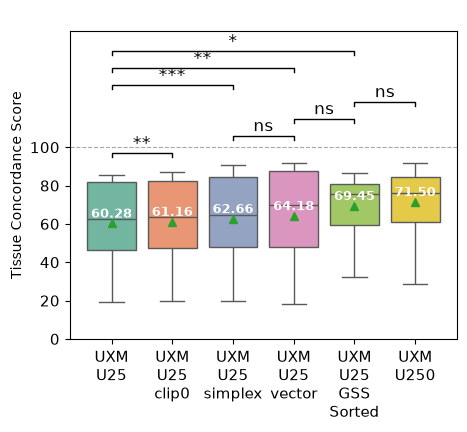

In [94]:
compare_methods_plot(
    new_baselines_tsc_aggregated,
    [
            "UXM U25",
            "UXM U25 clip0",
            "UXM U25 simplex",
            "UXM U25 vector",
            "UXM U25 GSS Sorted",
            "UXM U250",
        ],
    show_points=False,
    # baseline='UXM U25',
    pairs=[
        ("UXM U25", "UXM U25 clip0"),
        ("UXM U25", "UXM U25 vector"),
        ("UXM U25", "UXM U25 simplex"),
        ("UXM U25 simplex", "UXM U25 vector"),
        ("UXM U25", "UXM U25 GSS Sorted"),
        # ("UXM U25", "UXM U250"),
        ("UXM U25 GSS Sorted", "UXM U250"),
        ("UXM U25 vector", "UXM U25 GSS Sorted"),
    ],
    figsize=(5, 4),
    kind="box",
    bracket_step=0.12,
    test="wilcoxon",
    central_tendency="mean",
    show_ns=True,
    title=" ",
    ylabel="Tissue Concordance Score",
    save_path="uxm_rrbs_results.pdf",
)

(<Axes: title={'center': ' '}>,
                       UXM U25  UXM U25 clip0  UXM U25 simplex  UXM U25 vector  \
 UXM U25                   NaN      -0.881475        -2.375935       -3.896337   
 UXM U25 clip0        0.881475            NaN        -1.494461       -3.014862   
 UXM U25 simplex      2.375935       1.494461              NaN       -1.520402   
 UXM U25 vector       3.896337       3.014862         1.520402             NaN   
 UXM U25 GSS Sorted   9.169639       8.288164         6.793703        5.273302   
 UXM U250            11.222047      10.340573         8.846112        7.325710   
 
                     UXM U25 GSS Sorted   UXM U250  
 UXM U25                      -9.169639 -11.222047  
 UXM U25 clip0                -8.288164 -10.340573  
 UXM U25 simplex              -6.793703  -8.846112  
 UXM U25 vector               -5.273302  -7.325710  
 UXM U25 GSS Sorted                 NaN  -2.052408  
 UXM U250                      2.052408        NaN  ,
                    

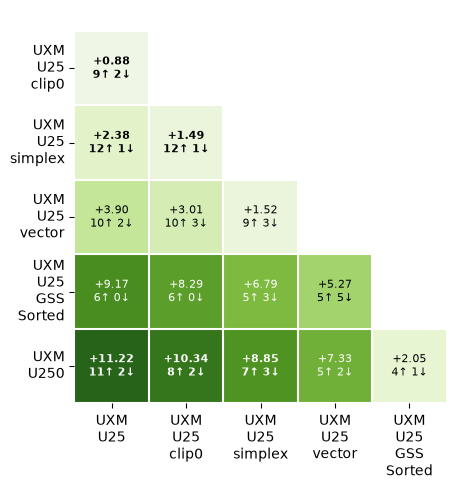

In [82]:
pairwise_difference_heatmap(
    new_baselines_tsc,
    [
        "UXM U25",
        "UXM U25 clip0",
        "UXM U25 simplex",
        "UXM U25 vector",
        "UXM U25 GSS Sorted",
        "UXM U250",
    ],
    test="wilcoxon",
    title=" ",
    cmap="PiYG",
    correction="fdr_bh",
    display_legend=False,
    figsize=(5, 5),
    save_path="uxm_rrbs_pvalues.pdf",
    annotation_format="tissue_counts",
    group_col= 'Biosample term name',
)

In [ ]:
new_results = our_results[17]


methods = new_results.columns[5:]
new_results_tsc = compute_on_target_proportions(
    new_results, tissue_mapping_df, methods
).dropna()

In [ ]:
new_results_tsc[new_results_tsc.columns[4:]].mean(axis=0)

Train Frequencies__Top156 Features__Cancer__Detector__MLP__clip0       0.696013
Train Frequencies__Top156 Features__Cancer__Detector__MLP__none        0.687482
Train Frequencies__Top156 Features__Cancer__Detector__MLP__simplex     0.706904
Train Frequencies__Top156 Features__Cancer__Detector__MLP__vector      0.703499
Train Frequencies__Top156 Features__Cancer__Detector__NNLS__clip0      0.649915
Train Frequencies__Top156 Features__Cancer__Detector__NNLS__none       0.639967
Train Frequencies__Top156 Features__Cancer__Detector__NNLS__simplex    0.673000
Train Frequencies__Top156 Features__Cancer__Detector__NNLS__vector     0.695346
Train Frequencies__Top156 Features__Cancer__Detector__PSLS__clip0      0.647808
Train Frequencies__Top156 Features__Cancer__Detector__PSLS__none       0.644459
Train Frequencies__Top156 Features__Cancer__Detector__PSLS__simplex    0.662557
Train Frequencies__Top156 Features__Cancer__Detector__PSLS__vector     0.668086
Train Frequencies__Top156 Features__Canc

In [ ]:
for i in range(2, len(files_with_results)):
    methods = our_results[i].columns[5:]
    syto_tsc = compute_on_target_proportions(
        our_results[i], tissue_mapping_df, methods
    ).dropna()
    print(files_with_results[i], np.round(syto_tsc[methods].to_numpy().flatten().mean(),3))
    syto_tsc = syto_tsc.merge(new_baselines_tsc[["file", "Celfie"]], on="file")

In [ ]:
i=16
methods = our_results[i].columns[5:]
syto_tsc = compute_on_target_proportions(
    our_results[i], tissue_mapping_df, methods
).dropna()
print(files_with_results[i], np.round(syto_tsc[methods].to_numpy().flatten().mean(),3))
syto_tsc = syto_tsc.merge(new_baselines_tsc[["file", "Celfie"]], on="file")
res = pd.concat([syto_tsc[syto_tsc.columns[4:]].apply(lambda x: np.round(np.mean(x)*100,2)), syto_tsc[syto_tsc.columns[4:]].apply(lambda x: np.round(np.std(x)*100,2))], axis=1)
res.columns = ["mean", "std"]
baseline = res["mean"].iloc[-1]
res["diff"] = res["mean"]-baseline
res["std"] = res["std"].apply(lambda x: f"({str(x)})")
res = res[:20]

strip_index = 3 
if len([x for x in syto_tsc.columns if "Cancer" in x]):
    strip_index += 1 
res["calibrator"] = res.index.to_series()[:20].apply(lambda x: x.split("__")[strip_index+1])
res["deconvolver"] = res.index.to_series()[:20].apply(lambda x: x.split("__")[strip_index])
res = res[['deconvolver', 'calibrator', "mean", "std","diff"]]
res["deconvolver"] = pd.Categorical(res["deconvolver"] , ["XGB", "MLP", "SWN", "NNLS", "PSLS"])
res["calibrator"] = pd.Categorical(res["calibrator"], ["none", "clip0", "simplex", "vector"])
p_values = []
for i in res.index:
    p_values.append(_run_test(syto_tsc, i, "Celfie", test = "ttest_rel"))
print(res.sort_values(by=["deconvolver", "calibrator"], ascending=True).to_string())

cfsort_results_v2/Cancer Detector/cfSort_rrbs_cancerdetector_uniformprior_prior_blengind.csv 0.667
                                                          deconvolver calibrator   mean      std  diff
uniform__Top156 Features__Cancer__Detector__XGB__none             XGB       none  68.87  (22.48)  4.94
uniform__Top156 Features__Cancer__Detector__XGB__clip0            XGB      clip0  69.85  (23.01)  5.92
uniform__Top156 Features__Cancer__Detector__XGB__simplex          XGB    simplex  71.74  (24.17)  7.81
uniform__Top156 Features__Cancer__Detector__XGB__vector           XGB     vector  72.24  (26.03)  8.31
uniform__Top156 Features__Cancer__Detector__MLP__none             MLP       none  64.89  (19.32)  0.96
uniform__Top156 Features__Cancer__Detector__MLP__clip0            MLP      clip0  66.19  (19.74)  2.26
uniform__Top156 Features__Cancer__Detector__MLP__simplex          MLP    simplex  67.14  (20.49)  3.21
uniform__Top156 Features__Cancer__Detector__MLP__vector           MLP     vec

In [ ]:
for i in range(2, len(files_with_results)):
    methods = our_results[i].columns[5:]
    syto_tsc = compute_on_target_proportions(
        our_results[i], tissue_mapping_df, methods
    ).dropna()
    print(files_with_results[i], np.round(syto_tsc[methods].to_numpy().flatten().mean(),3))
    syto_tsc = syto_tsc.merge(new_baselines_tsc[["file", "Celfie"]], on="file")
    compare_methods_plot(
        syto_tsc,
        syto_tsc.columns[4:],
        show_points=False,
        baseline="Celfie",
        figsize=(20, 6),
        kind="box",
        central_tendency="mean",
        bracket_step=0.12,
        test="ttest_rel",
        show_ns=True,
        title=f"{files_with_results[i]}",
        ylabel="Tissue Concordance Score",
        label_sep="__",
        inline_annotations=True,
        orient="v",
    )

Computing main-paper figures

In [ ]:
best_results = [
    (
        "cfsort_results_v2/Cancer Detector/cfSort_rrbs_cancerdetector_trainfreqprior_prior_blengind.csv",
        "Train Frequencies__Top156 Features__Cancer__Detector__XGB__vector",
    ),
    (
        "cfsort_results_v2/Soft Labels Canonical/top156features/cfSort_rrbs_dismir_soft_canonical_top156features_results_prior_blengind.csv",
        "Soft Labels Canonical__Top156 Features__Dismir__NNLS__vector",
    ),
    (
        "cfsort_results_v2/Soft Labels/cfSort_rrbs_methylbert_soft_prior_blengind.csv",
        "Soft Labels__Top156 Features__MethylBERT__SWN__simplex",
    ),
    (
        "cfsort_results_v2/Soft Labels No Pooling/cfSort_rrbs_lookup_soft_nopooling_prior_blengind.csv",
        "Soft Labels No Pooling__Top156 Features__Lookup__NNLS__vector",
    ),
    (
        "cfsort_results_v2/Hard Labels/top156features/cfSort_rrbs_dismir_hard_top156features_results_prior_blending.csv",
        "Hard Labels__Top156 Features__Dismir__NNLS__vector",
    ),
]

In [ ]:
from tqdm import tqdm

In [ ]:
main_tsc = new_baselines_tsc.copy(True)

for file, method in tqdm(best_results):
    target = [i for (i, x) in enumerate(files_with_results) if x == file][0]
    syto_tsc = compute_on_target_proportions(
        our_results[target], tissue_mapping_df, our_results[target].columns[5:]
    ).dropna()
    main_tsc = main_tsc.merge(syto_tsc[["file", method]], on="file")

100%|██████████| 5/5 [00:04<00:00,  1.07it/s]


In [ ]:
# compare_methods_plot(
#     main_tsc,
#     ['UXM U25', 'UXM U250',
#        'Train Frequencies__Cancer__Detector__XGB__vector',
#        'Soft Labels Canonical__Dismir__XGB__vector',
#        'Soft Labels__Dismir__XGB__vector',
#        'Soft Labels No Pooling__Dismir__SWN__vector',
#        'Hard Labels__Dismir__NNLS__vector'],
#     show_points=False,
#     baseline='UXM U25',
#     # pairs = [
#     #     ("UXM U25", "UXM U250"),
#     #     ("UXM U25", "UXM U25 vector"),
#     #     ("UXM U25", "UXM U25 simplex"),
#     #     ("UXM U25 simplex", "UXM U25 vector"),
#     #     ("UXM U25", "UXM U25 GSS Sorted"),
#     #     # ("UXM U25", "UXM U250"),
#     #     ("UXM U25 GSS Sorted", "UXM U250"),
#     #     ("UXM U25 simplex", "UXM U25 GSS Sorted"),
#     #     ],
#     figsize=(8,6),
#     orient = "h",
#     inline_annotations=True,
#     kind="box",
#     label_sep="__",
#     bracket_step=0.12,
#     test="ttest_rel",
#     show_ns=True, title=" ",
#     central_tendency = "mean",
#     ylabel = "Tissue Concordance Score",
#     save_path = "main_rrbs_results_h.pdf")

In [ ]:
main_tsc_forcd = main_tsc.copy(True)

In [ ]:
# main_tsc.rename(
#     columns={
#         'Soft Labels Canonical__Dismir__XGB__vector': 'Canonical__Soft Labels__Dismir__XGB__vector',
#         'Hard Labels__Dismir__NNLS__vector':'Hard Labels__w/ bckg.__Dismir__NNLS__vector',
#         'Soft Labels No Pooling__Dismir__SWN__vector': 'DD Soft Lb-s__w/o pool.__Dismir__SWN__vector',
#         'Soft Labels__Dismir__XGB__vector': 'DD Soft Lb-s__w/ pool.__Dismir__XGB__vector',
#         'Train Frequencies__Cancer__Detector__XGB__vector':'Training__Counts__Cancer__Detector__XGB__vector'
#     },
#     inplace=True
# )

In [ ]:
main_tsc_forcd.rename(
    columns={
        "UXM U25": "UXM__U25",
        "Soft Labels Canonical__Top156 Features__Dismir__NNLS__vector": "Canonical__SL",
        "Hard Labels__Top156 Features__Dismir__NNLS__vector": "HL__w/ bckg",
        "Soft Labels No Pooling__Top156 Features__Lookup__NNLS__vector": "DD SL__w/o pool",
        # "Soft Labels__Top156 Features__Dismir__XGB__vector": "DD SL__w/ pool",
        "Soft Labels__Top156 Features__MethylBERT__SWN__simplex": "DD SL__w/ pool",
        "Train Frequencies__Top156 Features__Cancer__Detector__XGB__vector": "Cancer__Detector",
        "UXM U250": "UXM__U250",
    },
    inplace=True,
)

In [ ]:
main_tsc_forcd_aggregated = (
    main_tsc_forcd[
        [
            "Biosample term name",
            "UXM__U25",
            "Celfie",
            "UXM__U250",
            "UXM U25 GSS Sorted",
            "Cancer__Detector",
            "Canonical__SL",
            "DD SL__w/ pool",
            "DD SL__w/o pool",
            "HL__w/ bckg",
        ]
    ]
    .groupby("Biosample term name")
    .aggregate("mean")
)

In [ ]:
main_tsc_forcd_aggregated.reset_index(inplace=True)

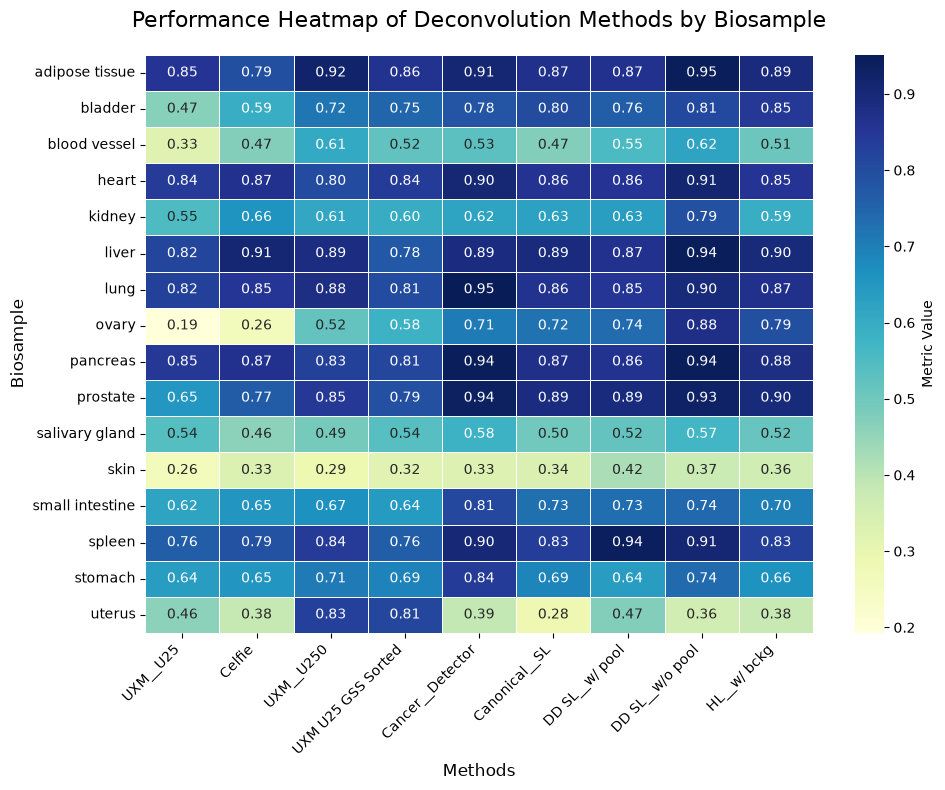

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def plot_deconvolution_heatmap(df, index="Biosample term name"):
    """
    Creates a heatmap using 'Biosample term name' as rows
    and deconvolution methods (columns 1 to 11) as columns.
    """
    # 1. Set the Biosample name as the index to serve as the y-axis labels
    # We use column 0 as the index
    plot_data = df.set_index(index)

    # 2. Ensure only the deconvolution method columns are selected
    # (Indexes 1 to 11 of the original dataframe)
    # Since we set index, we just take all remaining columns

    # 3. Handle potential non-numeric data
    plot_data = plot_data.apply(pd.to_numeric, errors="coerce")

    # 4. Set up the figure size
    plt.figure(figsize=(10, 8))

    # 5. Create the heatmap
    sns.heatmap(
        plot_data,
        annot=True,  # Display the values inside the cells
        fmt=".2f",  # Use 2 decimal places
        cmap="YlGnBu",  # Yellow-Green-Blue gradient (lighter = lower, darker = higher)
        linewidths=0.5,  # Add thin lines between cells for clarity
        cbar_kws={"label": "Metric Value"},
    )

    # 6. Formatting
    plt.title(
        "Performance Heatmap of Deconvolution Methods by Biosample", fontsize=16, pad=20
    )
    plt.xlabel("Methods", fontsize=12)
    plt.ylabel("Biosample", fontsize=12)
    plt.xticks(rotation=45, ha="right")  # Rotate method names for better fit

    plt.tight_layout()
    plt.show()


# Execution
plot_deconvolution_heatmap(main_tsc_forcd_aggregated)

# plot_deconvolution_heatmap(main_tsc_forcd[main_tsc_forcd["Biosample term name"]=="skin"][['file', 'UXM__U25', 'UXM U25 clip0', 'UXM U25 simplex',
#        'UXM U25 vector', 'UXM__U250', 'UXM U25 GSS Sorted', 'Cancer__Detector',
#        'Canonical__SL', 'DD SL__w/ pool', 'DD SL__w/o pool', 'HL__w/ bckg']], index="file")

In [ ]:
main_tsc_forcd.to_csv("tsc_best_methods.csv")

In [ ]:
main_tsc_forcd.columns

Index(['file', 'Biosample term name', 'expected_cell_types',
       'final_mapping_rate', 'Celfie', 'EpiDISH', 'Houseman_ineq', 'UXM__U25',
       'UXM__U250', 'UXM U25 GSS Sorted', 'Celfie clip0', 'Celfie simplex',
       'Celfie vector', 'EpiDISH clip0', 'EpiDISH simplex', 'EpiDISH vector',
       'Houseman_ineq clip0', 'Houseman_ineq simplex', 'Houseman_ineq vector',
       'UXM U25 clip0', 'UXM U25 simplex', 'UXM U25 vector',
       'Cancer__Detector', 'Canonical__SL', 'DD SL__w/ pool',
       'DD SL__w/o pool', 'HL__w/ bckg'],
      dtype='object')

(<Axes: title={'center': ' '}>,
                      Celfie  Canonical__SL  UXM__U250  HL__w/ bckg  \
 Celfie                  NaN      -5.794458  -7.033689    -7.259092   
 Canonical__SL      5.794458            NaN  -1.239231    -1.464634   
 UXM__U250          7.033689       1.239231        NaN    -0.225402   
 HL__w/ bckg        7.259092       1.464634   0.225402          NaN   
 DD SL__w/ pool     8.029128       2.234670   0.995438     0.770036   
 Cancer__Detector  10.665208       4.870750   3.631518     3.406116   
 DD SL__w/o pool   12.811271       7.016813   5.777581     5.552179   
 
                   DD SL__w/ pool  Cancer__Detector  DD SL__w/o pool  
 Celfie                 -8.029128        -10.665208       -12.811271  
 Canonical__SL          -2.234670         -4.870750        -7.016813  
 UXM__U250              -0.995438         -3.631518        -5.777581  
 HL__w/ bckg            -0.770036         -3.406116        -5.552179  
 DD SL__w/ pool               NaN         -

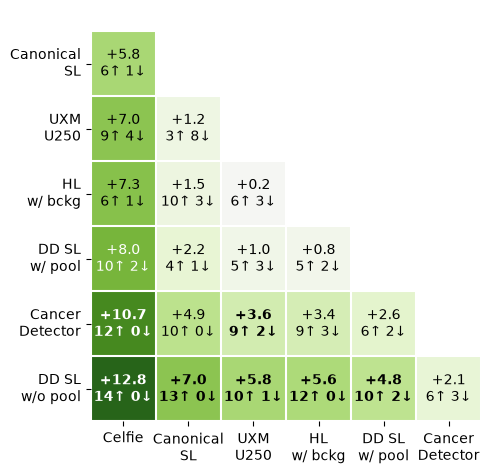

In [ ]:
pairwise_difference_heatmap(
    main_tsc_forcd,
    [
        "Celfie",
        "Canonical__SL",
        "UXM__U250",
        "HL__w/ bckg",
        "DD SL__w/ pool", 
        "Cancer__Detector",
        "DD SL__w/o pool",
    ],
    test="wilcoxon",
    title=" ",
    cmap="PiYG",
    save_path="main_rrbs_pvalues_numbers.pdf",
    figsize=(5, 5),
    label_sep="__",
    pvalue_decimals=3,
    # group_col= "Biosample term name",
    # correction="fdr_bh",
    diff_decimals=1,
    cell_fontsize=10,
    annotation_format="tissue_counts",
    group_col= 'Biosample term name',
    display_legend=False,
)

(<Axes: title={'center': ' '}>,
                    UXM__U25     Celfie  Canonical__SL  UXM__U250  HL__w/ bckg  \
 UXM__U25                NaN  -4.188358      -9.982816 -11.222047   -11.447450   
 Celfie             4.188358        NaN      -5.794458  -7.033689    -7.259092   
 Canonical__SL      9.982816   5.794458            NaN  -1.239231    -1.464634   
 UXM__U250         11.222047   7.033689       1.239231        NaN    -0.225402   
 HL__w/ bckg       11.447450   7.259092       1.464634   0.225402          NaN   
 DD SL__w/ pool    12.217486   8.029128       2.234670   0.995438     0.770036   
 Cancer__Detector  14.853566  10.665208       4.870750   3.631518     3.406116   
 DD SL__w/o pool   16.999629  12.811271       7.016813   5.777581     5.552179   
 
                   DD SL__w/ pool  Cancer__Detector  DD SL__w/o pool  
 UXM__U25              -12.217486        -14.853566       -16.999629  
 Celfie                 -8.029128        -10.665208       -12.811271  
 Canonical__SL 

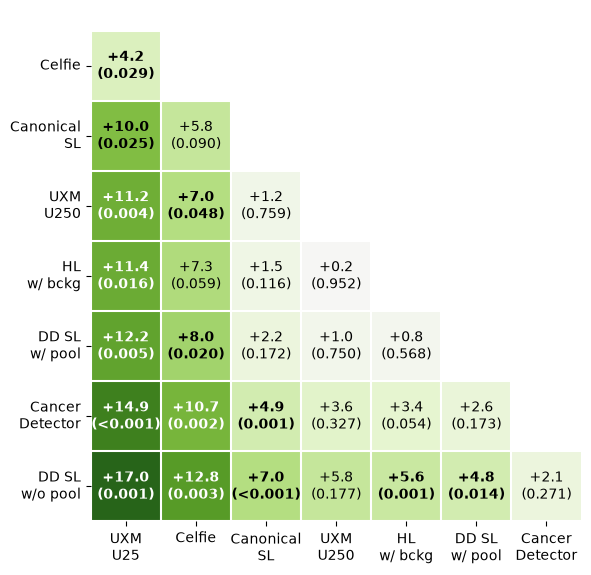

In [ ]:
pairwise_difference_heatmap(
    main_tsc_forcd_aggregated,
    [
        "UXM__U25",
        "Celfie",
        "Canonical__SL",
        "UXM__U250",
        "HL__w/ bckg",
        "DD SL__w/ pool", 
        "Cancer__Detector",
        "DD SL__w/o pool",
    ],
    test="ttest_rel",
    title=" ",
    cmap="PiYG",
    save_path="main_rrbs_pvalues_numbers.pdf",
    figsize=(6, 6),
    label_sep="__",
    pvalue_decimals=3,
    diff_decimals=1,
    cell_fontsize=10,
    annotation_format="pvalue",
    display_legend=False,
)

(<Axes: title={'center': ' '}>,
                    UXM__U25     Celfie  Canonical__SL  UXM__U250  HL__w/ bckg  \
 UXM__U25                NaN  -4.230423      -9.365423 -10.689346   -10.762923   
 Celfie             4.230423        NaN      -5.135000  -6.458923    -6.532500   
 Canonical__SL      9.365423   5.135000            NaN  -1.323923    -1.397500   
 UXM__U250         10.689346   6.458923       1.323923        NaN    -0.073577   
 HL__w/ bckg       10.762923   6.532500       1.397500   0.073577          NaN   
 DD SL__w/ pool    12.152846   7.922423       2.787423   1.463500     1.389923   
 Cancer__Detector  14.344077  10.113654       4.978654   3.654731     3.581154   
 DD SL__w/o pool   16.871654  12.641231       7.506231   6.182308     6.108731   
 
                   DD SL__w/ pool  Cancer__Detector  DD SL__w/o pool  
 UXM__U25              -12.152846        -14.344077       -16.871654  
 Celfie                 -7.922423        -10.113654       -12.641231  
 Canonical__SL 

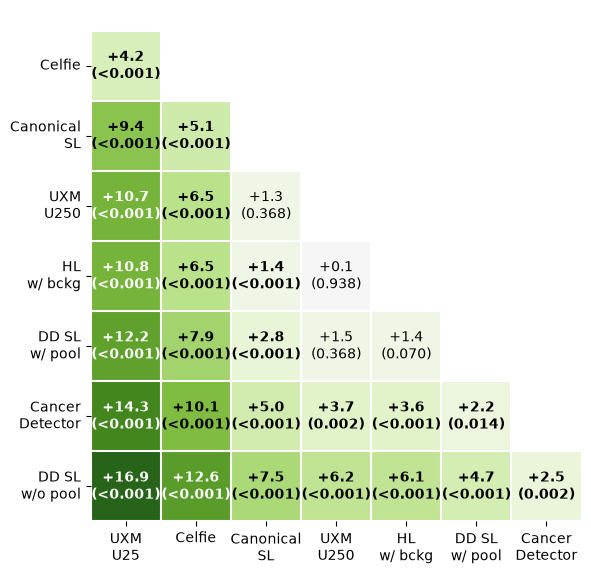

In [ ]:
pairwise_difference_heatmap(
    main_tsc_forcd,
    [
        "UXM__U25",
        "Celfie",
        "Canonical__SL",
        "UXM__U250",
        "HL__w/ bckg",
        "DD SL__w/ pool", 
        "Cancer__Detector",
        "DD SL__w/o pool",
    ],
    test="ttest_rel",
    title=" ",
    cmap="PiYG",
    save_path="main_rrbs_pvalues_numbers.pdf",
    figsize=(6, 6),
    label_sep="__",
    pvalue_decimals=3,
    correction="holm",
    diff_decimals=1,
    cell_fontsize=10,
    annotation_format="pvalue",
    display_legend=False,
)

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats


def random_simplex_tcs_null(
    observed_tcs,
    cell_types,
    method_cols,
    expected_col="expected_cell_types",
    samples_per_row=5000,
    mode="analytic",
    rng=None,
):
    """
    Null distribution of the Tissue Concordance Score (TCS) under a uniform
    random draw from the probability simplex.

    A random deconvolution over the given `cell_types` is a uniform draw from
    the (n-1)-simplex, i.e. Dirichlet(1, ..., 1) with n = len(cell_types). For
    a tissue whose expected-cell-type list has k entries (that are actually
    present among `cell_types`), the TCS -- the sum of those k on-target
    components -- is distributed exactly as Beta(k, n - k), with mean k / n.
    This gives a per-row chance baseline for the observed TCS.

    Parameters
    ----------
    observed_tcs : pd.DataFrame
        Output of `compute_on_target_proportions` (one row per file+biosample).
        Must contain `expected_col` and every column in `method_cols`.
    cell_types : sequence of str
        The full set of cell types the deconvolution predicts over (the simplex
        dimension). Pass e.g. `uxm_results["CellType"].unique()`. n = its size.
    method_cols : list of str
        Observed-TCS columns to score against the null.
    expected_col : str
        Column in `observed_tcs` holding the per-tissue expected-cell-type list.
    samples_per_row : int
        Null draws generated per row for the pooled plotting distribution.
    mode : {"analytic", "montecarlo"}
        "analytic": exact Beta(k, n-k) survival for p-values and Beta sampling
        for the null draws. "montecarlo": draw full Dirichlet simplices and sum
        the k on-target components (validates the analytic result).
    rng : np.random.Generator or None

    Returns
    -------
    per_row : pd.DataFrame
        Copy of `observed_tcs` augmented with:
          - k                 : number of expected cell types present in atlas
          - null_mean         : k / n  (expected random TCS)
          - null_q95          : 95th percentile of the Beta(k, n-k) null
          - <method>_p_random : P(TCS_random >= observed) for each method
    null_long : pd.DataFrame
        Long-format pooled null draws with columns
        [row_index, biosample, k, tcs], i.e. the overall chance distribution
        as a mixture over the biosamples actually present. Use it to histogram
        the null and overlay observed TCS.
    """
    if rng is None:
        rng = np.random.default_rng()
    if isinstance(method_cols, str):
        method_cols = [method_cols]

    ct_set = set(cell_types)
    n = len(ct_set)
    if n < 2:
        raise ValueError("need at least 2 cell types to define a simplex")

    per_row = observed_tcs.copy()

    def _k(expected):
        if not isinstance(expected, (list, tuple, set, np.ndarray)):
            return 0
        return len(ct_set.intersection(expected))

    per_row["k"] = per_row[expected_col].apply(_k)
    per_row["null_mean"] = per_row["k"] / n

    # 95th percentile of the per-tissue null (handy "chance ceiling")
    def _q95(k):
        if k <= 0:
            return 0.0
        if k >= n:
            return 1.0
        return float(stats.beta.ppf(0.95, k, n - k))

    per_row["null_q95"] = per_row["k"].apply(_q95)

    # ---- Random-draw p-value: P(TCS_random >= observed) --------------------
    def _p_random(observed, k):
        # observed TCS is a proportion in [0, 1]
        if k <= 0:
            # no reachable on-target mass -> TCS_random == 0 almost surely
            return 1.0 if observed <= 0 else 0.0
        if k >= n:
            return 1.0  # TCS_random == 1 almost surely
        return float(stats.beta.sf(observed, k, n - k))

    for m in method_cols:
        per_row[f"{m}_p_random"] = [
            _p_random(obs, k)
            for obs, k in zip(per_row[m].to_numpy(), per_row["k"].to_numpy())
        ]

    # ---- Pooled null draws for plotting ------------------------------------
    ct_list = list(cell_types)
    # cache one Dirichlet block per unique k for the MC path
    long_chunks = []
    for idx, row in per_row.iterrows():
        k = int(row["k"])
        biosample = row.get("Biosample term name", idx)
        if k <= 0:
            draws = np.zeros(samples_per_row)
        elif k >= n:
            draws = np.ones(samples_per_row)
        elif mode == "analytic":
            draws = rng.beta(k, n - k, size=samples_per_row)
        elif mode == "montecarlo":
            # on-target = the first k columns (exchangeable, so any k columns work)
            simplex = rng.dirichlet(np.ones(n), size=samples_per_row)
            draws = simplex[:, :k].sum(axis=1)
        else:
            raise ValueError("mode must be 'analytic' or 'montecarlo'")
        long_chunks.append(
            pd.DataFrame(
                {
                    "row_index": idx,
                    "biosample": biosample,
                    "k": k,
                    "tcs": draws,
                }
            )
        )

    null_long = (
        pd.concat(long_chunks, ignore_index=True)
        if long_chunks
        else pd.DataFrame(columns=["row_index", "biosample", "k", "tcs"])
    )
    return per_row, null_long

0      [Dermal-Fibro, Blood-T, Blood-Mono+Macro, Bloo...
2      [Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...
3      [Small-Int-Ep, Blood-T, Blood-B, Dermal-Fibro,...
6      [Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...
7      [Kidney-Ep, Blood-T, Blood-B, Blood-Mono+Macro...
                             ...                        
449    [Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...
450    [Pancreas-Acinar, Pancreas-Duct, Endothel, Blo...
452    [Dermal-Fibro, Smooth-Musc, Blood-Mono+Macro, ...
458                    [Ovary-Ep, Smooth-Musc, Endothel]
459    [Prostate-Ep, Blood-T, Endothel, Blood-Mono+Ma...
Name: expected_cell_types, Length: 260, dtype: object

n cell types (simplex dim) = 39
mean random TCS (over tissues) = 0.165
mean observed DD SL__w/ pool TCS      = 0.725
fraction of tissues where observed beats chance (p_random < 0.05): 93.08%


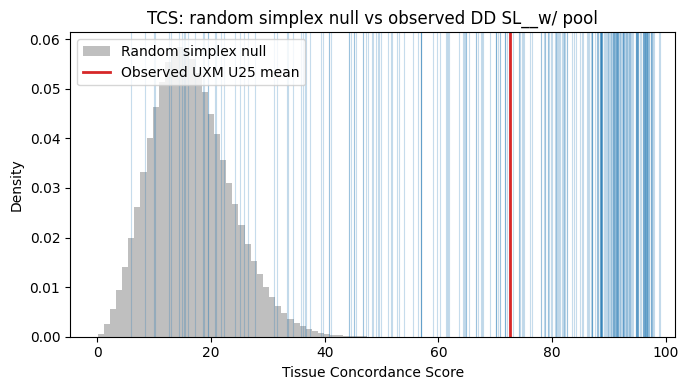

,Biosample term name,k,null_mean,null_q95,DD SL__w/ pool,DD SL__w/ pool_p_random
44,heart,6,0.153846,0.256958,0.9896,1.740699e-60
145,liver,8,0.205128,0.318318,0.9882,1.969971e-53
46,heart,6,0.153846,0.256958,0.9794,1.033753e-50
133,heart,6,0.153846,0.256958,0.9757,2.365017e-48
253,pancreas,6,0.153846,0.256958,0.9748,7.818110e-48
...,...,...,...,...,...,...
1,skin,6,0.153846,0.256958,0.1267,6.510053e-01
3,skin,6,0.153846,0.256958,0.1005,8.223983e-01
212,skin,6,0.153846,0.256958,0.0838,9.054742e-01
153,stomach,7,0.179487,0.288040,0.1013,9.155911e-01


In [ ]:
# Simplex dimension = every cell type the UXM deconvolution outputs
uxm_cell_types =  uxm_results["CellType"].unique()
method = "DD SL__w/ pool"

per_row, null_long = random_simplex_tcs_null(
    main_tsc_forcd,
    cell_types=uxm_cell_types,
    method_cols=[method],
    mode="analytic",           # switch to "montecarlo" to sanity-check
    rng=np.random.default_rng(0),
)

print(f"n cell types (simplex dim) = {len(uxm_cell_types)}")
print(f"mean random TCS (over tissues) = {per_row['null_mean'].mean():.3f}")
print(f"mean observed {method} TCS      = {main_tsc_forcd[method].mean():.3f}")
print(
    "fraction of tissues where observed beats chance (p_random < 0.05): "
    f"{(per_row[f'{method}_p_random'] < 0.05).mean():.2%}"
)

# Pooled null vs observed
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_long["tcs"] * 100, bins=60, density=True,
        alpha=0.5, label="Random simplex null", color="grey")
for v in main_tsc_forcd[method] * 100:
    ax.axvline(v, color="tab:blue", alpha=0.25, lw=0.8)
ax.axvline(main_tsc_forcd[method].mean() * 100, color="tab:red", lw=2,
           label="Observed UXM U25 mean")
ax.set_xlabel("Tissue Concordance Score")
ax.set_ylabel("Density")
ax.set_title(f"TCS: random simplex null vs observed {method}")
ax.legend()
plt.tight_layout()
plt.show()

# Per-tissue chance p-values
per_row[["Biosample term name", "k", "null_mean", "null_q95",
         method, f'{method}_p_random']].sort_values(f'{method}_p_random')

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter


def tissue_ubiquity(expected_df, expected_col="expected_cell_types"):
    """
    Per cell type: in how many tissues it is 'expected'. Ubiquitous cell types
    (e.g. Endothel) appear in most tissues and so carry little tissue-specific
    information. `idf` is a specificity weight = log(T / n_tissues_expected).
    """
    lists = expected_df[expected_col]
    T = len(lists)
    cnt = Counter()
    for lst in lists:
        if isinstance(lst, (list, tuple, set, np.ndarray)):
            for c in set(lst):
                cnt[c] += 1
    ub = pd.DataFrame(
        {"n_tissues_expected": pd.Series(cnt)}
    )
    ub["ubiquity"] = ub["n_tissues_expected"] / T
    ub["idf"] = np.log(T / ub["n_tissues_expected"])
    ub.index.name = "cell_type"
    return ub.sort_values("ubiquity", ascending=False)


def decompose_tcs_difference(
    deconv_df,
    expected_df,
    method_a,
    method_b,
    biosample_col="Biosample term name",
    file_col="file",
    celltype_col="CellType",
    tissue_key="cfsort_tissue_name",
    expected_col="expected_cell_types",
    ubiquity_threshold=0.5,
):
    """
    Attribute the mean TCS gap between `method_a` and `method_b` to individual
    cell types, and separate the part driven by ubiquitous cell types (expected
    in many tissues) from the tissue-specific part.

    `deconv_df` is the SAME long (one row per CellType x file x biosample) frame
    fed to `compute_on_target_proportions`, and must contain both `method_a` and
    `method_b` as columns. To compare two models that live in different frames
    (e.g. UXM vs syto), merge them first on [celltype_col, file_col,
    biosample_col] so both proportion columns sit side by side.

    Returns
    -------
    per_ct : pd.DataFrame  (one row per cell type, sorted by |delta|)
        tcs_contrib__<a>, tcs_contrib__<b> : each cell type's additive share of
            that method's mean TCS (columns each sum to the method's mean TCS).
        delta        : contrib_a - contrib_b (sums to the total TCS gap).
        share_of_gap : delta / total_gap.
        n_tissues_expected, ubiquity, idf : from `tissue_ubiquity`.
    summary : dict
        total_gap, gap_from_ubiquitous, gap_from_specific, frac_from_ubiquitous
        (fraction of the gap coming from cell types with ubiquity >= threshold).
    """
    merged = deconv_df.merge(
        expected_df, how="right", left_on=biosample_col, right_on=tissue_key
    )

    def _on_target(row):
        e = row[expected_col]
        return isinstance(e, (list, tuple, set, np.ndarray)) and row[celltype_col] in e

    merged["on_target"] = merged.apply(_on_target, axis=1)

    # number of samples we average over
    n_samples = merged[[file_col, biosample_col]].drop_duplicates().shape[0]

    print(n_samples)

    merged["contrib_a"] = (merged[method_a].fillna(0) * merged["on_target"]).astype(float)
    merged["contrib_b"] = (merged[method_b].fillna(0) * merged["on_target"]).astype(float)

    per_ct = merged.groupby(celltype_col)[["contrib_a", "contrib_b"]].sum() / n_samples
    per_ct.columns = [f"tcs_contrib__{method_a}", f"tcs_contrib__{method_b}"]
    per_ct["delta"] = per_ct.iloc[:, 0] - per_ct.iloc[:, 1]

    total_gap = per_ct["delta"].sum()
    per_ct["share_of_gap"] = per_ct["delta"] / total_gap if total_gap != 0 else np.nan

    ub = tissue_ubiquity(expected_df, expected_col)
    per_ct = per_ct.join(ub[["n_tissues_expected", "ubiquity", "idf"]])
    per_ct = per_ct.sort_values("delta", key=lambda s: s.abs(), ascending=False)

    ub_mask = per_ct["ubiquity"] >= ubiquity_threshold
    gap_ubiq = per_ct.loc[ub_mask, "delta"].sum()
    summary = {
        "method_a": method_a,
        "method_b": method_b,
        "n_samples": n_samples,
        "total_gap": float(total_gap),
        "gap_from_ubiquitous": float(gap_ubiq),
        "gap_from_specific": float(total_gap - gap_ubiq),
        "frac_from_ubiquitous": float(gap_ubiq / total_gap) if total_gap != 0 else np.nan,
        "ubiquity_threshold": ubiquity_threshold,
    }
    return per_ct, summary

In [ ]:
per_ct, summary = decompose_tcs_difference(
    uxm_results.merge(our_results[12][["file", "Biosample term name","CellType", "Soft Labels No Pooling__Top156 Features__Lookup__NNLS__vector"]], on=["file", "Biosample term name", "CellType"]),                 # raw long frame, has UXM_U25 / UXM_U250 columns
    tissue_mapping_df,
    method_a="UXM_U25",
    method_b="Soft Labels No Pooling__Top156 Features__Lookup__NNLS__vector",
    ubiquity_threshold=0.5,
)

print(f"total TCS gap ({summary['method_a']} - {summary['method_b']}): "
      f"{summary['total_gap']*100:+.2f} pts")
print(f"  from ubiquitous cell types (ubiquity >= {summary['ubiquity_threshold']}): "
      f"{summary['gap_from_ubiquitous']*100:+.2f} pts "
      f"({summary['frac_from_ubiquitous']:.0%} of the gap)")
print(f"  from tissue-specific cell types: {summary['gap_from_specific']*100:+.2f} pts")

# Which cell types drive the gap, and how ubiquitous are they?
per_ct.assign(
    delta_pts=lambda d: (d["delta"] * 100).round(2),
    share=lambda d: (d["share_of_gap"] * 100).round(1),
)[["delta_pts", "share", "ubiquity", "n_tissues_expected"]].head(12)

260
total TCS gap (UXM_U25 - Soft Labels No Pooling__Top156 Features__Lookup__NNLS__vector): -16.87 pts
  from ubiquitous cell types (ubiquity >= 0.5): -13.78 pts (82% of the gap)
  from tissue-specific cell types: -3.09 pts


,delta_pts,share,ubiquity,n_tissues_expected
CellType,,,,
Smooth-Musc,-6.56,38.9,0.5625,9.0
Endothel,-4.62,27.4,0.8750,14.0
Dermal-Fibro,-2.25,13.3,0.6250,10.0
Prostate-Ep,-1.54,9.1,0.0625,1.0
Blood-T,1.44,-8.5,0.9375,15.0
Kidney-Ep,-1.33,7.9,0.0625,1.0
Pancreas-Acinar,-1.06,6.3,0.0625,1.0
Blood-B,-1.05,6.2,0.5625,9.0
Heart-Fibro,0.67,-3.9,0.0625,1.0


In [ ]:
import numpy as np
import pandas as pd

# Baseline "deconvolvers" are methods in their own right -> they identify a group
# instead of being a nested variant to take a range over.
BASELINE_DECONVOLVERS = frozenset({
    "uxm", "celfie", "celfieish", "epidish", "epidish_houseman",
})
UXM_CALIBRATOR_SUFFIXES = ("clip0", "simplex", "vector")
FIELDS = ("Prior", "FeatureScheme", "LabelingScheme", "Classifier",
          "Deconvolver", "Calibrator")

def _parse_uxm_column(col):
    """'UXM_U25_clip0' -> atlas U25, calibrator clip0.  'UXM_U250' -> calibrator none."""
    rest = col[len("UXM_"):] if col.startswith("UXM_") else col
    calibrator = "none"
    for suf in UXM_CALIBRATOR_SUFFIXES:
        if rest.endswith("_" + suf):
            rest, calibrator = rest[: -(len(suf) + 1)], suf
            break
    return {"Prior": "", "FeatureScheme": rest, "LabelingScheme": "",
            "Classifier": "UXM", "Deconvolver": "UXM", "Calibrator": calibrator,
            "is_baseline": True}


def _parse_by_config(col, config_cols, nested_fields, sep, baseline_deconvolvers):
    """
    Invert `pivot_results`: the column is sep.join(row[c] for c in config_cols).

    Trailing fields (Deconvolver, Calibrator) are peeled off from the RIGHT, so a
    Classifier value that itself contains `sep` ('Dismir__U250Inference',
    'Cancer__Detector') survives intact. Only the LAST key field may contain sep.
    """
    nested_fields = [c for c in config_cols if c in set(nested_fields)]
    key_cols = [c for c in config_cols if c not in set(nested_fields)]

    parts = col.rsplit(sep, len(nested_fields)) if nested_fields else [col]
    head, tail = parts[0], parts[1:]
    head_parts = head.split(sep, max(len(key_cols) - 1, 0))

    fields = {f: "" for f in FIELDS}
    for name, val in zip(key_cols, head_parts):
        fields[name] = val
    for name, val in zip(nested_fields, tail):
        fields[name] = val
    fields["is_baseline"] = fields["Deconvolver"].strip().lower() in baseline_deconvolvers
    return fields


def _parse_column(col, spec, sep, baseline_deconvolvers):
    if callable(spec):
        out = {f: "" for f in FIELDS}
        out.update(spec(col))
        out.setdefault("is_baseline", False)
        return out
    if spec == "uxm" or (spec is None and str(col).startswith("UXM")):
        return _parse_uxm_column(col)
    if isinstance(spec, dict):
        config_cols = spec["config_cols"]
        nested = spec.get("nested_fields", ("Deconvolver", "Calibrator"))
    else:
        config_cols = spec or ("LabelingScheme", "FeatureScheme", "Classifier",
                               "Deconvolver", "Calibrator")
        nested = ("Deconvolver", "Calibrator")
    return _parse_by_config(col, config_cols, nested, sep, baseline_deconvolvers)


def scheme_proportion_ranges(
    dfs,
    expected_df,
    cell_types=None,
    specs=None,
    dataset_names=None,
    biosample_col="Biosample term name",
    file_col="file",
    celltype_col="CellType",
    tissue_key="cfsort_tissue_name",
    expected_col="expected_cell_types",
    tissues=None,
    expected_filter="all",        # "all" | "expected" | "unexpected"
    groupby_tissue=False,
    value_cols=None,
    fill_missing=0.0,
    sep="__",
    baseline_deconvolvers=BASELINE_DECONVOLVERS,
):
    """
    For every model identity -- LabelingScheme x FeatureScheme x Classifier
    (x Prior for Cancer Detector, x the specific baseline deconvolver for
    UXM/CelFiE/EpiDISH) -- report the RANGE of mean predicted proportions taken
    over all its nested Deconvolver+Calibrator variants, per selected cell type,
    averaged over the samples whose tissue appears in `expected_df`.

    Parameters
    ----------
    dfs : list[pd.DataFrame]
        The pivoted frames (one row per CellType x file x biosample; one numeric
        column per scheme), i.e. exactly what your loop puts in `our_results`.
    specs : list | dict | None
        Per-frame description of how the scheme columns were built, parallel to
        `dfs` (or keyed by dataset name). Each entry is one of:
          * the `config_cols` tuple you passed to `pivot_results`
          * {"config_cols": (...), "nested_fields": ("Calibrator",)} to pin which
            fields are nested
          * "uxm"        -> the UXM_U25 / UXM_U25_clip0 / UXM_U250 layout
          * a callable col -> dict of FIELDS
          * None         -> auto: "uxm" for UXM* columns, else the default
                            (LabelingScheme, FeatureScheme, Classifier,
                             Deconvolver, Calibrator)
        A Deconvolver landing in `baseline_deconvolvers` is moved into the group
        key automatically, so celfie / epidish / ... each get their own row.
    cell_types : list[str] | None
        Cell types to report on; None = all present.
    expected_filter : {"all","expected","unexpected"}
        Restrict to samples where the cell type is / is not expected in the tissue.
    groupby_tissue : bool
        Compute ranges per tissue instead of pooling tissues.
    fill_missing : float | None
        NaN proportions -> this value before averaging. None = drop them.

    Returns
    -------
    ranges : pd.DataFrame
        One row per (dataset, group, [tissue], cell type): n_schemes, min, max,
        range, rel_range, mean, median, std, scheme_at_min, scheme_at_max,
        n_samples, range_str.
    per_scheme : pd.DataFrame
        The underlying per-variant means (one row per nested Deconvolver+
        Calibrator), so you can drill into any range.
    """
    if expected_filter not in ("all", "expected", "unexpected"):
        raise ValueError("expected_filter must be 'all', 'expected' or 'unexpected'")
    baseline_deconvolvers = frozenset(x.lower() for x in baseline_deconvolvers)

    if dataset_names is None:
        dataset_names = [f"dataset_{i}" for i in range(len(dfs))]
    if len(dataset_names) != len(dfs):
        raise ValueError("dataset_names must match dfs in length")

    expected_map = {
        r[tissue_key]: (set(r[expected_col])
                        if isinstance(r[expected_col], (list, tuple, set, np.ndarray))
                        else set())
        for _, r in expected_df.iterrows()
    }
    allowed = set(expected_map) if tissues is None else set(tissues) & set(expected_map)

    frames = []
    for i, (name, df) in enumerate(zip(dataset_names, dfs)):
        spec = (specs.get(name) if isinstance(specs, dict)
                else (specs[i] if specs is not None else None))
        cols = (value_cols.get(name) if isinstance(value_cols, dict) else value_cols)
        if cols is None:
            cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        cols = [c for c in cols if c in df.columns]
        if not cols:
            continue

        sub = df[df[biosample_col].isin(allowed)]
        if cell_types is not None:
            sub = sub[sub[celltype_col].isin(cell_types)]
        if sub.empty:
            continue

        long = sub.melt(
            id_vars=[file_col, biosample_col, celltype_col],
            value_vars=cols, var_name="scheme", value_name="value",
        )

        on_target = [ct in expected_map.get(ts, set())
                     for ct, ts in zip(long[celltype_col], long[biosample_col])]
        long["on_target"] = on_target
        if expected_filter == "expected":
            long = long[long["on_target"]]
        elif expected_filter == "unexpected":
            long = long[~long["on_target"]]
        if long.empty:
            continue

        long["value"] = (long["value"].fillna(fill_missing) if fill_missing is not None
                         else long["value"])
        if fill_missing is None:
            long = long.dropna(subset=["value"])
        long["sample_id"] = long[file_col].astype(str) + "|" + long[biosample_col].astype(str)

        parsed = {c: _parse_column(c, spec, sep, baseline_deconvolvers)
                  for c in long["scheme"].unique()}

        def _group_label(f):
            bits = [f["Prior"], f["LabelingScheme"], f["FeatureScheme"], f["Classifier"]]
            if f["is_baseline"] and f["Deconvolver"]:
                bits.append(f["Deconvolver"])
            return " | ".join(b for b in bits if b)

        def _nested_label(f):
            bits = ([] if f["is_baseline"] else [f["Deconvolver"]]) + [f["Calibrator"]]
            return sep.join(b for b in bits if b) or "<single>"

        for fname in FIELDS:
            long[fname] = long["scheme"].map(lambda c, f=fname: parsed[c][f])
        long["is_baseline"] = long["scheme"].map(lambda c: parsed[c]["is_baseline"])
        long["BaselineDeconvolver"] = np.where(long["is_baseline"], long["Deconvolver"], "")
        long["group"] = long["scheme"].map(lambda c: _group_label(parsed[c]))
        long["nested"] = long["scheme"].map(lambda c: _nested_label(parsed[c]))

        keys = ["group", "Prior", "LabelingScheme", "FeatureScheme", "Classifier",
                "BaselineDeconvolver", celltype_col]
        if groupby_tissue:
            keys.insert(-1, biosample_col)

        agg = (long.groupby(keys + ["nested", "Deconvolver", "Calibrator"], dropna=False)
                   .agg(mean_proportion=("value", "mean"),
                        n_samples=("sample_id", "nunique"))
                   .reset_index())
        agg.insert(0, "dataset", name)
        frames.append(agg)

    if not frames:
        return pd.DataFrame(), pd.DataFrame()

    per_scheme = pd.concat(frames, ignore_index=True)

    group_cols = ["dataset", "group", "Prior", "LabelingScheme", "FeatureScheme",
                  "Classifier", "BaselineDeconvolver"]
    if groupby_tissue:
        group_cols.append(biosample_col)
    group_cols.append(celltype_col)

    g = per_scheme.groupby(group_cols, dropna=False)["mean_proportion"]
    ranges = g.agg(n_schemes="size", min="min", max="max",
                   mean="mean", median="median", std="std").reset_index()
    ranges["range"] = ranges["max"] - ranges["min"]
    ranges["rel_range"] = np.where(ranges["mean"] > 0, ranges["range"] / ranges["mean"], np.nan)
    ranges["scheme_at_min"] = per_scheme.loc[g.idxmin().values, "nested"].values
    ranges["scheme_at_max"] = per_scheme.loc[g.idxmax().values, "nested"].values
    ranges["n_samples"] = per_scheme.groupby(group_cols, dropna=False)["n_samples"].max().values
    ranges["range_str"] = [f"{lo:.4f}–{hi:.4f}" for lo, hi in zip(ranges["min"], ranges["max"])]

    ordered = ["n_schemes", "n_samples", "min", "max", "range", "rel_range",
               "mean", "median", "std", "scheme_at_min", "scheme_at_max", "range_str"]
    ranges = (ranges[group_cols + ordered]
              .sort_values(group_cols[:-1] + ["range"],
                           ascending=[True] * (len(group_cols) - 1) + [False])
              .reset_index(drop=True))
    return ranges, per_scheme


In [ ]:
our_results.append(uxm_results)

In [ ]:
our_specs.append("uxm" if file.split("/")[split_index] == "UXM" else config_cols)

('LabelingScheme', 'FeatureScheme', 'Classifier', 'Deconvolver', 'Calibrator')

In [ ]:
ranges, per_scheme = scheme_proportion_ranges(
    our_results,
    tissue_mapping_df,
    cell_types=["Blood-T", "Endothel", "Blood-B"],
    specs=our_specs
)

In [ ]:
our_results[0] = our_results[0].drop(columns = ["UXM_U25_clip0","UXM_U25_simplex", "UXM_U25_vector"])

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(ranges.to_string())

       dataset                                                   group              Prior          LabelingScheme    FeatureScheme             Classifier BaselineDeconvolver  CellType  n_schemes  n_samples       min       max     range  rel_range      mean    median       std scheme_at_min scheme_at_max      range_str
0    dataset_0                                         U25 | UXM | UXM                                                         U25                    UXM                 UXM  Endothel          4        260  0.146452  0.184794  0.038342   0.230348  0.166453  0.167282  0.016128          none        vector  0.1465–0.1848
1    dataset_0                                         U25 | UXM | UXM                                                         U25                    UXM                 UXM   Blood-T          4        260  0.039135  0.050025  0.010890   0.238709  0.045620  0.046661  0.004706        vector          none  0.0391–0.0500
2    dataset_0                          

In [ ]:
our_results[0][our_results[0]["CellType"]=="Endothel"]["UXM_U25"].mean()

np.float64(0.11765519328214971)

### Analysis of aggregated rrbs matrices

In [ ]:
import os
import pickle

In [ ]:
deconvolutions_path = "/data/dmytro/Experiments/cfsort_rrbs/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_d041_postfiltered_min_length_50_soft_labels_pooled_jakkard/pseudobulk/deconvolutions/"

In [ ]:
import os
import pickle
import pandas as pd
from pathlib import Path


def aggregate_low_coverage_dmrs(
    deconvolutions_path,
    thresholds=(0, 5, 10, 30),
    inner_filename="dmr_aggregated.pkl",
    label_col="dmr_ctype_label",
    reads_col="n_reads",
    verbose=True,
):
    """
    For each per-file deconvolution result, identify DMR cell-type labels whose
    n_reads falls below each given threshold, count them, and collect the labels.

    Parameters
    ----------
    deconvolutions_path : str or Path
        Directory whose immediate subdirectories each contain `inner_filename`.
    thresholds : tuple of int
        Read-count thresholds. The first one is treated as exact equality
        (n_reads == 0); the rest as strict inequalities (n_reads < t).
        Adjust the rule below if you want a different convention.
    inner_filename : str
        Name of the pickle file inside each subdirectory.
    label_col, reads_col : str
        Column names in the loaded dataframe.
    verbose : bool
        Print a warning for files that fail to load or are missing columns.

    Returns
    -------
    pd.DataFrame
        One row per file with columns:
            file_name,
            count_eq_0, count_lt_5, count_lt_10, count_lt_30,
            labels_eq_0, labels_lt_5, labels_lt_10, labels_lt_30
        (column names follow the thresholds you pass in)
    """
    deconvolutions_path = Path(deconvolutions_path)

    # Build (column_suffix, predicate) for each threshold.
    # First threshold uses ==, others use <.
    rules = []
    for i, t in enumerate(thresholds):
        if i == 0:
            rules.append((f"eq_{t}", lambda s, t=t: s == t))
        else:
            rules.append((f"lt_{t}", lambda s, t=t: s < t))

    rows = []
    subdirs = sorted(p for p in deconvolutions_path.iterdir() if p.is_dir())

    for subdir in subdirs:
        pkl_path = subdir / inner_filename
        if not pkl_path.exists():
            if verbose:
                print(f"[skip] {subdir.name}: {inner_filename} not found")
            continue

        try:
            with open(pkl_path, "rb") as f:
                df = pickle.load(f)
        except Exception as e:
            if verbose:
                print(f"[skip] {subdir.name}: failed to load ({e})")
            continue

        if not isinstance(df, pd.DataFrame):
            if verbose:
                print(
                    f"[skip] {subdir.name}: pickle is {type(df).__name__}, not DataFrame"
                )
            continue
        if label_col not in df.columns or reads_col not in df.columns:
            if verbose:
                print(f"[skip] {subdir.name}: missing required columns")
            continue

        row = {"file_name": subdir.name}
        for suffix, predicate in rules:
            mask = predicate(df[reads_col])
            labels = df.loc[mask, label_col].tolist()
            row[f"count_{suffix}"] = int(mask.sum())
            row[f"labels_{suffix}"] = labels
        rows.append(row)

    # Preserve a sensible column order
    count_cols = [f"count_{suffix}" for suffix, _ in rules]
    label_cols = [f"labels_{suffix}" for suffix, _ in rules]
    result = pd.DataFrame(rows, columns=["file_name"] + count_cols + label_cols)
    return result

In [ ]:
aggregated_stats = aggregate_low_coverage_dmrs(
    deconvolutions_path,
    thresholds=(0, 5, 10, 30),
    inner_filename="dmr_aggregated.pkl",
    label_col="dmr_ctype_label",
    reads_col="n_reads",
    verbose=True,
)

In [ ]:
aggregated_stats["file_name"] = aggregated_stats["file_name"].apply(
    lambda x: x.split("_")[0]
)

In [ ]:
aggregated_stats

,file_name,count_eq_0,count_lt_5,count_lt_10,count_lt_30,labels_eq_0,labels_lt_5,labels_lt_10,labels_lt_30
0,GSM7427236,3,4,4,7,"[11, 16, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 9, 11, 15, 16, 19, 37]"
1,GSM7427237,2,4,4,6,"[11, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 10, 11, 15, 16, 37]"
2,GSM7427238,3,4,4,6,"[11, 16, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 11, 15, 16, 32, 37]"
3,GSM7427239,2,3,3,6,"[11, 37]","[11, 16, 37]","[11, 16, 37]","[0, 10, 11, 15, 16, 37]"
4,GSM7427240,1,2,3,5,[11],"[11, 37]","[0, 11, 37]","[0, 11, 15, 16, 37]"
...,...,...,...,...,...,...,...,...,...
516,GSM7427756,3,3,3,5,"[11, 16, 37]","[11, 16, 37]","[11, 16, 37]","[0, 11, 15, 16, 37]"
517,GSM7427757,1,2,2,3,[11],"[11, 37]","[11, 37]","[11, 16, 37]"
518,GSM7427758,2,3,3,4,"[11, 37]","[11, 16, 37]","[11, 16, 37]","[11, 15, 16, 37]"
519,GSM7427759,1,2,2,2,[11],"[11, 37]","[11, 37]","[11, 37]"


In [ ]:
aggregated_stats[
    aggregated_stats["file_name"].apply(
        lambda x: x in methylbert_soft_tsc["file"].to_list()
    )
].count_lt_30.value_counts()

count_lt_30
5    142
6     96
4     17
7      3
2      1
3      1
Name: count, dtype: int64

### Correlation between tcs and various pseudobulk metrics

In [ ]:
pseudobulk_metrics = pd.read_csv("pseudobulk_metrics.tsv", delimiter="\t")

In [ ]:
RESULTS_PER_TISSUE = False

In [ ]:
all_tsc_results = []
all_tsc_results_full = []  # NEW: collect non-aggregated melted results

for res in our_results:
    if "UXM_U25" in res.columns:
        syto_tsc = uxm_tsc
    else:
        syto_tsc = compute_on_target_proportions(
            res, tissue_mapping_df, res.columns[5:]
        ).dropna()

    syto_tsc_melted = syto_tsc.melt(
        id_vars=[
            "file",
            "Biosample term name",
            "expected_cell_types",
            "final_mapping_rate",
        ]
    )
    if RESULTS_PER_TISSUE:
        aggregated_tsc = (
            syto_tsc_melted[["variable", "Biosample term name", "value"]]
            .groupby(["Biosample term name", "variable"])
            .aggregate("mean")
            .reset_index()
        )
        aggregated_tsc = (
            aggregated_tsc[["variable", "value"]]
            .groupby("variable")
            .aggregate("mean")
            .reset_index()
        )
    else:
        aggregated_tsc = (
            syto_tsc_melted[["variable", "value"]]
            .groupby("variable")
            .aggregate("mean")
            .reset_index()
        )

    # NEW: helper that adds the metadata columns the same way for any frame
    # that contains a "variable" column.
    def _add_metadata_columns(df, is_uxm):
        df = df.copy()
        if is_uxm:
            df["Classifier"] = "UXM"
            df["Deconvolver"] = "UXM"
            df["Calibrator"] = df["variable"].apply(
                lambda x: x.split("_")[2] if len(x.split("_")) == 2 else ""
            )
            # Make sure all frames have the same set of columns so concat is clean.
            df["Prior"] = ""
            df["LabelingScheme"] = ""
            df["FeatureScheme"] = ""
        else:
            classifier = df["variable"].apply(lambda x: x.split("__")[2])
            offset = 0
            if classifier.iloc[0] == "Cancer":
                df["Classifier"] = "Cancer Detector"
                offset = 1
                df["Prior"] = df["variable"].apply(lambda x: x.split("__")[0])
                df["LabelingScheme"] = ""
            else:
                df["Classifier"] = classifier
                df["Prior"] = ""
                df["LabelingScheme"] = df["variable"].apply(lambda x: x.split("__")[0])
            df["FeatureScheme"] = df["variable"].apply(lambda x: x.split("__")[1])
            df["Deconvolver"] = df["variable"].apply(
                lambda x: x.split("__")[3 + offset]
            )
            df["Calibrator"] = df["variable"].apply(lambda x: x.split("__")[4 + offset])
        return df

    is_uxm = "UXM_U25" in res.columns
    aggregated_tsc = _add_metadata_columns(aggregated_tsc, is_uxm)
    full_tsc = _add_metadata_columns(syto_tsc_melted, is_uxm)  # NEW

    all_tsc_results.append(aggregated_tsc)
    all_tsc_results_full.append(full_tsc)  # NEW


all_tsc_results = pd.concat(all_tsc_results, axis=0)
all_tsc_results_full = pd.concat(all_tsc_results_full, axis=0)  # NEW

tsc_to_pseudobulk_mapping_classifiers = {
    "UXM": "UXM",
    "Cancer Detector": "CancerDetector",
    "Dismir": "Dismir",
    "MethylBERT": "MethylBERT",
    "Lookup": "Lookup Classifier",
}

tsc_to_pseudobulk_mapping_calibrators = {
    "": np.nan,
    "none": np.nan,
    "clip0": "Lin. clip+norm",
    "simplex": "Lin. simplex",
    "vector": "Vec. scaling",
}

tsc_to_pseudobulk_mapping_prior = {
    "Train Frequencies": "Training Counts",
    "uniform": "Uniform",
    np.nan: np.nan,
    "": np.nan,
}

tsc_to_pseudobulk_mapping_labeling = {
    np.nan: np.nan,
    "": np.nan,
    "Soft Labels Canonical": "Canonical Soft Labels",
    "Soft Labels": "Data-Driven Soft-Labels (with pooling)",
    "Soft Labels No Pooling": "Data-Driven Soft-Labels (without pooling)",
    "Hard Labels": "Hard Labels",
}

tsc_to_pseudobulk_mapping_features = {
    np.nan: np.nan,
    "": np.nan,
    "Top156 Features": "Top 10%",
    "Diag + Bckg": "Diag. + Bckg.",
}


def _apply_pseudobulk_mappings(df):  # NEW
    df = df.copy()
    df["Classifier"] = df["Classifier"].apply(
        lambda x: tsc_to_pseudobulk_mapping_classifiers.get(x)
    )
    df["Calibrator"] = df["Calibrator"].apply(
        lambda x: tsc_to_pseudobulk_mapping_calibrators.get(x)
    )
    df["Prior"] = df["Prior"].apply(lambda x: tsc_to_pseudobulk_mapping_prior.get(x))
    df["LabelingScheme"] = df["LabelingScheme"].apply(
        lambda x: tsc_to_pseudobulk_mapping_labeling.get(x)
    )
    df["FeatureScheme"] = df["FeatureScheme"].apply(
        lambda x: tsc_to_pseudobulk_mapping_features.get(x)
    )
    return df


all_tsc_results = _apply_pseudobulk_mappings(all_tsc_results)
all_tsc_results_full = _apply_pseudobulk_mappings(all_tsc_results_full)  # NEW

_rename_map = {
    "LabelingScheme": "Labeling Scheme",
    "FeatureScheme": "Feature Scheme",
    "value": "TCS",
}
all_tsc_results.rename(columns=_rename_map, inplace=True)
all_tsc_results_full.rename(columns=_rename_map, inplace=True)  # NEW

all_tsc_results.reset_index(inplace=True)
all_tsc_results_full.reset_index(inplace=True)

In [ ]:
def build_tcs_comparison_tables(
    df,
    deconvolvers,
    calibrators,
    target,
    feature_schemes=None,
    labeling_schemes=None,
    priors=None,
    classifiers=None,
    test="wilcoxon",
    correction=None,
    score_col="TCS",
    sample_id_cols=("file", "Biosample term name"),
):
    """
    Build (mean, std, pvalue) tables from a long-format TCS dataframe.

    Rows: (Deconvolver, Calibrator) pairs from the user-supplied lists.
    Cols: cartesian product of the column-axis fields you supply
          (Feature Scheme, Labeling Scheme, Prior, Classifier). Any of
          those passed as None are collapsed (averaged over).

    Each cell holds the mean / std / p-value of `score_col` over samples.
    The p-value is computed pairwise against `target`, which is a
    fully-specified external method given as a dict, e.g.

        target = {"Deconvolver": "UXM", "Classifier": "UXM",
                  "Calibrator": np.nan,
                  "variable": "UXM U25"}    # optional extra constraints

    Any field not in the dict is treated as "don't care". The target rows
    are pulled from `df` independently of the row/column filters and
    aggregated per sample (mean over remaining within-target rows) before
    the paired test.

    Parameters
    ----------
    df : DataFrame
        Long-format frame.
    deconvolvers, calibrators : list
        Row axis. NaN is allowed and matched correctly.
    target : dict
        Field -> value mapping that selects the reference method's rows
        from `df`. Use np.nan for fields that should match NaN.
    feature_schemes, labeling_schemes, priors, classifiers : list or None
        Column-axis filters. None means collapse that axis.
    test, correction : passed to `pairwise_pvalue_matrix`.
    score_col : str
    sample_id_cols : tuple
        Columns identifying a sample (used for the paired pivot).

    Returns
    -------
    mean_df, std_df, pval_df
    """
    from itertools import product

    # --- helpers ---------------------------------------------------------
    def _isin_with_nan(series, values):
        """Like Series.isin but treats np.nan in `values` as matching NaN."""
        values = list(values)
        has_nan = any(isinstance(v, float) and np.isnan(v) for v in values)
        non_nan = [v for v in values if not (isinstance(v, float) and np.isnan(v))]
        mask = series.isin(non_nan)
        if has_nan:
            mask = mask | series.isna()
        return mask

    def _eq_with_nan(series, value):
        if isinstance(value, float) and np.isnan(value):
            return series.isna()
        return series == value

    # --- 1. Active column-axis fields -----------------------------------
    col_field_specs = [
        ("Feature Scheme", feature_schemes),
        ("Labeling Scheme", labeling_schemes),
        ("Prior", priors),
        ("Classifier", classifiers),
    ]
    active_col_fields = [(f, vals) for f, vals in col_field_specs if vals is not None]
    active_col_names = [f for f, _ in active_col_fields]

    # --- 2. Filter the long frame for the table body -------------------
    sub = df.copy()
    sub = sub[_isin_with_nan(sub["Deconvolver"], deconvolvers)]
    sub = sub[_isin_with_nan(sub["Calibrator"], calibrators)]
    for field, vals in active_col_fields:
        sub = sub[_isin_with_nan(sub[field], vals)]
    if sub.empty:
        raise ValueError("No rows match the requested filters for the table body.")

    # --- 3. Row + column keys -------------------------------------------
    sub = sub.assign(
        _row_key=list(zip(sub["Deconvolver"], sub["Calibrator"])),
        _col_key=(
            list(zip(*[sub[f] for f in active_col_names]))
            if active_col_names
            else [()] * len(sub)
        ),
    )

    row_keys_all = [(d, c) for d in deconvolvers for c in calibrators]
    present_rows = {tuple(rk) for rk in sub["_row_key"]}

    def _row_in_present(rk):
        # Match treating NaN == NaN.
        for prk in present_rows:
            if all(
                (
                    isinstance(a, float)
                    and np.isnan(a)
                    and isinstance(b, float)
                    and np.isnan(b)
                )
                or a == b
                for a, b in zip(rk, prk)
            ):
                return True
        return False

    row_keys = [rk for rk in row_keys_all if _row_in_present(rk)]

    if active_col_names:
        col_value_lists = [vals for _, vals in active_col_fields]
        col_keys_all = list(product(*col_value_lists))
        present_cols = set(sub["_col_key"])
        col_keys = [ck for ck in col_keys_all if ck in present_cols]
    else:
        col_keys = [()]

    # --- 4. Resolve the target -----------------------------------------
    target_rows = df.copy()
    for field, value in target.items():
        if field not in target_rows.columns:
            raise ValueError(f"target field {field!r} is not a column in df.")
        target_rows = target_rows[_eq_with_nan(target_rows[field], value)]
    if target_rows.empty:
        raise ValueError(f"target {target} matched no rows in df.")

    # If multiple `variable` values match the target spec, collapse them
    # by averaging per sample so we end up with a single target column.
    target_per_sample = (
        target_rows.groupby(list(sample_id_cols))[score_col].mean().rename("__target__")
    )

    # --- 5. Mean and std over the table body ---------------------------
    grouped = sub.groupby(["_row_key", "_col_key"])[score_col]
    mean_long = grouped.mean()
    std_long = grouped.std()

    def _to_matrix(series):
        return (
            series.unstack("_col_key")
            .reindex(index=row_keys, columns=col_keys)
            .astype(float)
        )

    mean_df = _to_matrix(mean_long)
    std_df = _to_matrix(std_long)

    # --- 6. P-values vs the external target ----------------------------
    pval_df = pd.DataFrame(index=row_keys, columns=col_keys, dtype=float)
    sample_id_cols = list(sample_id_cols)
    TARGET_NAME = "__target__"

    def _tuples_equal(a, b):
        return all(
            (
                isinstance(x, float)
                and np.isnan(x)
                and isinstance(y, float)
                and np.isnan(y)
            )
            or x == y
            for x, y in zip(a, b)
        )

    for rk in row_keys:
        mask = sub["_row_key"].apply(lambda x, rk=rk: _tuples_equal(x, rk))
        row_sub = sub[mask]
        wide = row_sub.pivot_table(
            index=sample_id_cols,
            columns="_col_key",
            values=score_col,
            aggfunc="mean",
        )
        cols_here = [c for c in col_keys if c in wide.columns]
        if not cols_here:
            continue

        wide = wide.join(target_per_sample, how="left")
        if wide[TARGET_NAME].dropna().empty:
            continue

        name_map = {c: repr(c) for c in cols_here}
        wide_named = wide[cols_here + [TARGET_NAME]].rename(columns=name_map)
        methods = [name_map[c] for c in cols_here] + [TARGET_NAME]
        pmat = pairwise_pvalue_matrix(
            wide_named, methods=methods, test=test, correction=correction
        )
        for c in cols_here:
            pval_df.iat[
                pval_df.index.get_loc(rk),
                pval_df.columns.get_loc(c),
            ] = pmat.loc[TARGET_NAME, name_map[c]]

    # --- 7. MultiIndex labels ------------------------------------------
    mean_df.index = pd.MultiIndex.from_tuples(
        row_keys, names=["Deconvolver", "Calibrator"]
    )
    std_df.index = mean_df.index
    pval_df.index = mean_df.index
    if active_col_names:
        mean_df.columns = pd.MultiIndex.from_tuples(col_keys, names=active_col_names)
        std_df.columns = mean_df.columns
        pval_df.columns = mean_df.columns

    return mean_df, std_df, pval_df

In [ ]:
all_tsc_results_full["Feature Scheme"].unique()

array([nan, 'Top 10%', 'Diag. + Bckg.'], dtype=object)

In [ ]:
mean_df, std_df, pval_df = build_tcs_comparison_tables(
    all_tsc_results_full,
    deconvolvers=["XGB", "MLP", "SWN", "NNLS", "PSLS"],
    calibrators=[np.nan, "Lin. clip+norm", "Lin. simplex", "Vec. scaling"],
    classifiers=["Lookup Classifier", "MethylBERT", "Dismir"],
    feature_schemes=["Diag. + Bckg."],
    labeling_schemes=["Hard Labels", "Canonical Soft Labels"],
    priors=None,
    target={
        "Deconvolver": "UXM",
        "Classifier": "UXM",
        "variable": "UXM U25",  # pin to the specific UXM variant you want
    },
    test="ttest_rel",
    correction=None,
)

In [ ]:
def format_tcs_latex_table(
    mean_df,
    std_df,
    pval_df,
    tcs_threshold,
    pvalue_threshold=0.05,
    decimals=3,
    green_color="green",
    red_color="red",
    min_intensity=5,
    max_intensity=60,
    max_difference_intensity=20,
    nan_str="--",
    caption=None,
    label=None,
    font_size="footnotesize",
    column_format=None,
):
    """
    Render a LaTeX table from (mean, std, pvalue) matrices with cell coloring.

    Each cell shows "mean (std)". Coloring rules:
      - Green if mean > tcs_threshold AND p-value < pvalue_threshold
      - Red   if mean < tcs_threshold AND p-value < pvalue_threshold
      - No color otherwise (including NaN p-values)

    Parameters
    ----------
    mean_df, std_df, pval_df : DataFrame
        Identically-shaped frames as returned by `build_tcs_comparison_tables`.
        May have MultiIndex on rows and/or columns.
    tcs_threshold : float
        Reference TCS value. Cells above it (and significant) go green,
        below (and significant) go red.
    pvalue_threshold : float, default 0.05
        Significance cutoff for coloring.
    decimals : int, default 3
        Decimal places for mean and std.
    green_color, red_color : str
        xcolor color specs (e.g. 'green!25', 'ForestGreen!30', 'YellowGreen').
    nan_str : str
        Placeholder for NaN means.
    caption, label : str or None
        If given, wraps the tabular in a `table` environment.
    column_format : str or None
        Override the LaTeX column spec. Default is 'l' per index level + 'c'
        per data column.

    Returns
    -------
    str
        LaTeX source. Requires \\usepackage{xcolor} (with the [table] option,
        i.e. \\usepackage[table]{xcolor}) and \\usepackage{booktabs} in the
        preamble.
    """
    if not (mean_df.shape == std_df.shape == pval_df.shape):
        raise ValueError("mean_df, std_df, and pval_df must have the same shape.")

    def _esc(s):
        """Escape LaTeX special characters in a label string."""
        if s is None:
            return ""
        s = str(s)
        # Order matters: backslash first.
        for a, b in [
            ("\\", r"\textbackslash{}"),
            ("&", r"\&"),
            ("%", r"\%"),
            ("$", r"\$"),
            ("#", r"\#"),
            ("_", r"\_"),
            ("{", r"\{"),
            ("}", r"\}"),
            ("~", r"\textasciitilde{}"),
            ("^", r"\textasciicircum{}"),
        ]:
            s = s.replace(a, b)
        return s

    def _fmt_label(x):
        if x is None:
            return ""
        if isinstance(x, float) and np.isnan(x):
            return nan_str
        return _esc(x)

    def _tuple_or_scalar(x):
        return x if isinstance(x, tuple) else (x,)

    # --- Index/column level info ----------------------------------------
    row_levels = mean_df.index.nlevels
    col_levels = mean_df.columns.nlevels
    row_names = list(mean_df.index.names) if row_levels > 1 else [mean_df.index.name]
    col_names = (
        list(mean_df.columns.names) if col_levels > 1 else [mean_df.columns.name]
    )
    row_names = ["" if n is None else n for n in row_names]
    col_names = ["" if n is None else n for n in col_names]

    n_rows, n_cols = mean_df.shape

    if column_format is None:
        column_format = "l" * row_levels + "c" * n_cols

    # --- Header ---------------------------------------------------------
    lines = []
    lines.append(r"\begin{tabular}{" + column_format + "}")
    lines.append(r"\toprule")

    # Top header rows: one row per column-index level.
    # For multi-level columns, emit a row per level. We don't merge cells
    # across repeated values -- it's safer and still readable.
    for lvl in range(col_levels):
        # Left padding cells: row-index header names go on the LAST header row.
        if lvl < col_levels - 1:
            left = [""] * row_levels
        else:
            left = [_esc(n) for n in row_names]
        right = []
        for col in mean_df.columns:
            tup = _tuple_or_scalar(col)
            right.append(_fmt_label(tup[lvl]))
        lines.append(" & ".join(left + right) + r" \\")

    # If column has names but only one level, also emit a name row above
    # the values when that name is non-empty -- skipped here for simplicity:
    # a single-level column header is already covered by the loop above.

    lines.append(r"\midrule")

    # --- Body ----------------------------------------------------------
    means = mean_df.to_numpy() * 100
    stds = std_df.to_numpy() * 100
    pvals = pval_df.to_numpy()

    fmt = f"{{:.{decimals}f}}"

    for i, row_idx in enumerate(mean_df.index):
        row_tup = _tuple_or_scalar(row_idx)
        cells = [_fmt_label(v) for v in row_tup]
        for j in range(n_cols):
            m, s, p = means[i, j], stds[i, j], pvals[i, j]
            if np.isnan(m):
                content = nan_str
            else:
                s_str = fmt.format(s) if not np.isnan(s) else nan_str
                content = f"{fmt.format(m)} ({s_str})"

            # Decide coloring.
            color = None
            if (
                not np.isnan(m)
                and not np.isnan(p)
                and p < pvalue_threshold
                and m != tcs_threshold
            ):
                diff = abs(m - tcs_threshold)
                # Linear scale from min_intensity at diff~0 to max_intensity
                # at diff>=max_difference_intensity.
                if max_difference_intensity > 0:
                    frac = min(diff / max_difference_intensity, 1.0)
                else:
                    frac = 1.0
                intensity = int(
                    round(min_intensity + frac * (max_intensity - min_intensity))
                )
                base = green_color if m > tcs_threshold else red_color
                color = f"{base}!{intensity}"

            if color is not None:
                cell = r"\cellcolor{" + color + "}" + content
            else:
                cell = content
            cells.append(cell)
        lines.append(" & ".join(cells) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    table_body = "\n".join(lines)
    # Wrap tabular in \footnotesize so the table fits on the page.
    if font_size:
        table_body = "{\\" + font_size + "\n" + table_body + "\n}"

    if caption is not None or label is not None:
        wrapped = [r"\begin{table}[ht]", r"\centering", table_body]
        if caption is not None:
            wrapped.append(r"\caption{" + caption + "}")
        if label is not None:
            wrapped.append(r"\label{" + label + "}")
        wrapped.append(r"\end{table}")
        return "\n".join(wrapped)

    return table_body

In [ ]:
latex = format_tcs_latex_table(
    mean_df,
    std_df,
    pval_df,
    tcs_threshold=uxm_tsc["UXM U25"].mean() * 100,  # e.g. UXM U25's mean TCS
    pvalue_threshold=0.001,
    decimals=2,
    max_difference_intensity=10,
    green_color="teal",
    red_color="magenta",
    caption="TCS comparison vs UXM U25.",
    label="tab:tcs_vs_uxm",
)
print(latex)

\begin{table}[ht]
\centering
{\footnotesize
\begin{tabular}{llcccc}
\toprule
 &  & Diag. + Bckg. & Diag. + Bckg. & Diag. + Bckg. & Diag. + Bckg. \\
 &  & Hard Labels & Hard Labels & Canonical Soft Labels & Canonical Soft Labels \\
Deconvolver & Calibrator & MethylBERT & Dismir & MethylBERT & Dismir \\
\midrule
XGB & -- & \cellcolor{magenta!60}47.41 (14.54) & 60.43 (16.60) & \cellcolor{magenta!60}39.47 (13.10) & 57.01 (18.31) \\
XGB & Lin. clip+norm & \cellcolor{magenta!60}49.48 (15.47) & 62.12 (17.19) & \cellcolor{magenta!60}43.62 (14.47) & 58.12 (18.95) \\
XGB & Lin. simplex & \cellcolor{magenta!53}50.90 (16.29) & 64.18 (18.25) & \cellcolor{magenta!60}43.77 (14.83) & 59.79 (19.98) \\
XGB & Vec. scaling & \cellcolor{magenta!39}53.43 (18.46) & \cellcolor{teal!38}65.76 (19.69) & \cellcolor{magenta!60}44.59 (16.89) & 60.62 (22.13) \\
MLP & -- & \cellcolor{magenta!60}36.89 (25.52) & 63.75 (24.52) & \cellcolor{magenta!60}37.37 (22.24) & \cellcolor{magenta!60}39.51 (35.90) \\
MLP & Lin. clip

In [ ]:
pseudobulk_metrics.loc[
    (pseudobulk_metrics["Feature Scheme"].isna())
    & (pseudobulk_metrics["Classifier"] != "UXM"),
    "Feature Scheme",
] = "Top 10%"

In [ ]:
combined_metrics = pseudobulk_metrics.merge(
    all_tsc_results,
    on=[
        "Classifier",
        "Deconvolver",
        "Calibrator",
        "Feature Scheme",
        "Labeling Scheme",
        "Prior",
    ],
)

/tmp/ipykernel_17149/1233254354.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[metrics + [target_col]] = df[metrics + [target_col]].apply(pd.to_numeric, errors='coerce')


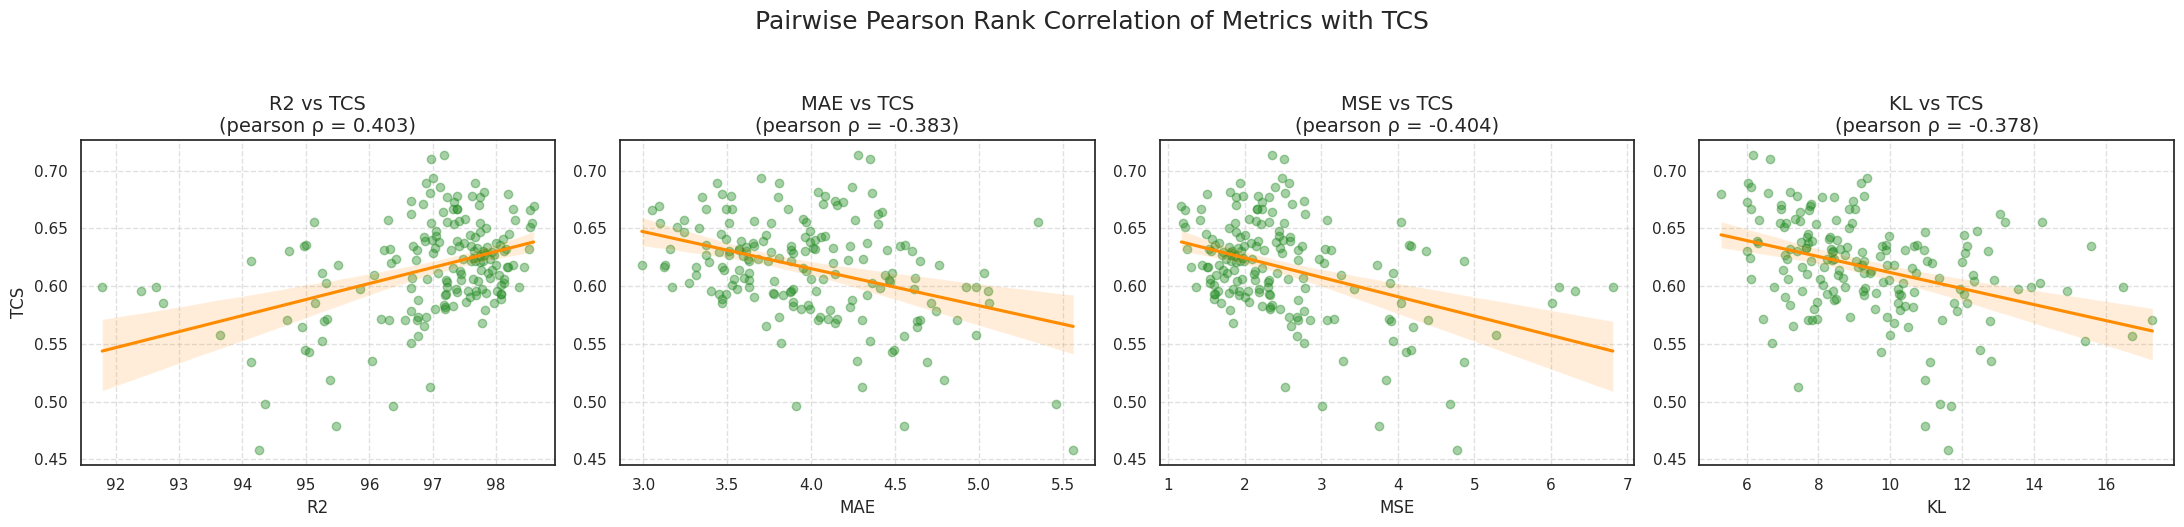

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Placeholder columns
metrics = ["R2", "MAE", "MSE", "KL", "TCS"]

# Set style
sns.set_theme(style="white")


# Define a function to create the plots to keep it clean
def plot_correlations(df, target_col="TCS", method="spearman"):
    metrics = ["R2", "MAE", "MSE", "KL"]

    # Ensure columns are numeric
    df[metrics + [target_col]] = df[metrics + [target_col]].apply(
        pd.to_numeric, errors="coerce"
    )

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"Pairwise {method.capitalize()} Rank Correlation of Metrics with {target_col}",
        fontsize=18,
        y=1.05,
    )

    for i, metric in enumerate(metrics):
        # Calculate correlation using the specified method
        corr_val = df[metric].corr(df[target_col], method=method)

        sns.regplot(
            ax=axes[i],
            x=metric,
            y=target_col,
            data=df,
            scatter_kws={"alpha": 0.4, "color": "forestgreen"},
            line_kws={"color": "darkorange"},
        )

        axes[i].set_title(
            f"{metric} vs {target_col}\n({method} ρ = {corr_val:.3f})", fontsize=14
        )
        axes[i].set_xlabel(metric, fontsize=12)
        axes[i].set_ylabel(target_col if i == 0 else "", fontsize=12)
        axes[i].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_correlations(
    combined_metrics[
        (combined_metrics["Classifier"] != "Lookup Classifier")
        & (combined_metrics["Feature Scheme"] != "Diag. + Bckg.")
        & (combined_metrics["Classifier"] != "UXM")
        & (combined_metrics["KL"] < 20)
    ],
    method="pearson",
)